## Phase 1: Environment Setup & Spatial Foundation

### 1. Environment Setup & Data Loading
**Objective:** Import necessary libraries, set up the environment, and load the cleaned transactional dataset (`merged_transactions.csv`) for analysis.

In [9]:
!pip install folium

In [10]:
import pandas as pd
import folium
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [11]:
df_transactions = pd.read_csv('generated/merged_transactions.csv') 
df_transactions.head(6)

,NO_TOKEN_CB,CD_TICKET_UNIQUE,DT_VENTE,TS_VENTE,ID_MAG_TIERS,ID_ARTICLE,MT_TTC_NET,TX_TVA,QT_UVC,QT_POIDS,...,LB_DESIGNATION_LIEU_DE_VENTE,LB_ADRESSE,CD_POSTAL,LB_VILLE,LATITUDE,LONGITUDE,DT_OUVERTURE,TOTAL_QTY,QTY_PROMO_NAT,QTY_PROMO_STORE
0,A33FB7919EEAB875A8AF4493286211B29F49B0746939EF...,4949207601061614291,2025-12-05,2025-12-05 08:46:00,79,100000000008209,1.09,0.055,0.55,0.550,...,Vaulx en Velin,2 RUE JEAN ET JOSEPHINE PEYRI,69120,VAULX EN VELIN,45.785683,4.926692,2007-05-16,1.100,0.0,0.0
1,A33FB7919EEAB875A8AF4493286211B29F49B0746939EF...,4949207601061614291,2025-12-05,2025-12-05 08:46:00,79,100000000009130,0.50,0.055,0.20,0.200,...,Vaulx en Velin,2 RUE JEAN ET JOSEPHINE PEYRI,69120,VAULX EN VELIN,45.785683,4.926692,2007-05-16,0.400,0.0,0.0
2,2755B58F8A00BA3FA60E9E69A1951194F048FDF5FB0C2C...,4945949002201926787,2025-12-01,2025-12-01 14:15:00,1296,100000000009179,0.99,0.055,1.00,0.000,...,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680090,3.138073,2018-02-14,1.000,0.0,0.0
3,2755B58F8A00BA3FA60E9E69A1951194F048FDF5FB0C2C...,4945949002201926787,2025-12-01,2025-12-01 14:15:00,1296,100000000005706,1.56,0.055,0.19,0.195,...,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680090,3.138073,2018-02-14,0.385,0.0,0.0
4,7B6704A84131A41FF8F2CB121FD2517FE65F52B714B4C4...,4964269402201934474,2025-12-22,2025-12-22 19:09:00,1297,80000000000C1HB,5.39,0.055,1.00,0.110,...,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680090,3.138073,2018-02-14,1.110,0.0,0.0
5,7B6704A84131A41FF8F2CB121FD2517FE65F52B714B4C4...,4964269402201934474,2025-12-22,2025-12-22 19:09:00,1297,80000000000C2OR,4.34,0.055,1.00,0.217,...,Wasquehal,10 rue Jean Jaures,59290,Wasquehal,50.680090,3.138073,2018-02-14,1.217,0.0,0.0


In [12]:
df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1304346 entries, 0 to 1304345
Data columns (total 35 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   NO_TOKEN_CB                   1304346 non-null  str    
 1   CD_TICKET_UNIQUE              1304346 non-null  int64  
 2   DT_VENTE                      1304346 non-null  str    
 3   TS_VENTE                      1304346 non-null  str    
 4   ID_MAG_TIERS                  1304346 non-null  int64  
 5   ID_ARTICLE                    1304346 non-null  str    
 6   MT_TTC_NET                    1304346 non-null  float64
 7   TX_TVA                        1304346 non-null  float64
 8   QT_UVC                        1304346 non-null  float64
 9   QT_POIDS                      1304346 non-null  float64
 10  IS_PROMO_NATIONALE            1304346 non-null  int64  
 11  IS_PROMO_MAGASIN              1304346 non-null  int64  
 12  HOUR                          1304346 n

### 2. Store Spatial Validation & Base Mapping
**Objective:** Extract unique store geographical information, validate coordinate integrity (checking for zero/null values), and plot the baseline store network using Folium.

In [13]:
# store info list
unique_stores = df_transactions[[
    'ID_LIEU_DE_VENTE',              
    'LB_DESIGNATION_LIEU_DE_VENTE',
    'LB_VILLE', 
    'CD_POSTAL',
    'LATITUDE',                    
    'LONGITUDE'                     
]].drop_duplicates().sort_values('ID_LIEU_DE_VENTE')


unique_stores.reset_index(drop=True, inplace=True)

print(f"Number of stores: {len(unique_stores)}。")
display(unique_stores)

invalid_coords = unique_stores[
    (unique_stores['LATITUDE'] == 0) | 
    (unique_stores['LONGITUDE'] == 0)
]

if len(invalid_coords) > 0:
    print(f"\n Warning：have {len(invalid_coords)} coordinate seem invalid (equal 0):")
    display(invalid_coords)
else:
    print("\n all coordinates are valid (None 0)")

Number of stores: 11。


,ID_LIEU_DE_VENTE,LB_DESIGNATION_LIEU_DE_VENTE,LB_VILLE,CD_POSTAL,LATITUDE,LONGITUDE
0,106,Vaulx en Velin,VAULX EN VELIN,69120,45.785683,4.926692
1,163,Perpignan,PERPIGNAN,66000,42.671413,2.888161
2,180,Meyzieu,MEYZIEU,69330,45.772190,4.987101
3,195,Hautepierre,STRASBOURG,67200,48.587494,7.700943
4,220,Wasquehal,Wasquehal,59290,50.680090,3.138073
5,277,Polygone,PERPIGNAN,66000,42.738544,2.890626
6,286,Fleury sur Orne,Fleury Sur Orne,14123,49.141180,-0.372080
7,414,Mions,Mions,69780,45.680557,4.956442
8,532,Decines,DECINES-CHARPIEU,69150,45.746082,4.934131
9,534,Bron,BRON,69500,45.727703,4.915211



 all coordinates are valid (None 0)


In [14]:
# map stores location
center_lat = unique_stores['LATITUDE'].mean()
center_lon = unique_stores['LONGITUDE'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

for idx, row in unique_stores.iterrows():
    folium.Marker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        popup=f"{row['LB_DESIGNATION_LIEU_DE_VENTE']} ({row['LB_VILLE']})",
        tooltip=f"Store ID: {row['ID_LIEU_DE_VENTE']}",
        icon=folium.Icon(color='blue', icon='shopping-cart')
    ).add_to(m)

print("Store location map：")
m

Store location map：


## Phase 2: Cross-Store Cannibalization & Network Analysis

### 3. Geospatial Cannibalization: Distance vs. Shared Customers
**Objective:** Utilize the Haversine formula to calculate the exact distance between all possible store pairs. Then, perform a self-merge on customer tokens to identify "Shared Customers" and analyze the correlation between geographic distance and customer overlap. Analyze Adjacent Stores

In [15]:
print("Analyze Adjacent Stores")

# 1. Haversine Formula
def calculate_distance(row):
    coord_a = store_coords.get(row['ID_LIEU_DE_VENTE_A'])
    coord_b = store_coords.get(row['ID_LIEU_DE_VENTE_B'])
    
    if not coord_a or not coord_b:
        return None

    lon1, lat1, lon2, lat2 = map(radians, [
        coord_a['LONGITUDE'], coord_a['LATITUDE'], 
        coord_b['LONGITUDE'], coord_b['LATITUDE']
    ])

    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 
    return c * r

Analyze Adjacent Stores


In [16]:
# prepare dict
store_coords = unique_stores.set_index('ID_LIEU_DE_VENTE')[['LATITUDE', 'LONGITUDE']].to_dict('index')
store_names = unique_stores.set_index('ID_LIEU_DE_VENTE')['LB_DESIGNATION_LIEU_DE_VENTE'].to_dict()


In [17]:
# create store pairs
print("Generating store pairs with shared customers...")

df_cross = df_transactions[['NO_TOKEN_CB', 'ID_LIEU_DE_VENTE']].drop_duplicates()

# Self-Merge
df_pairs = df_cross.merge(
    df_cross,
    on='NO_TOKEN_CB',
    suffixes=('_A', '_B')
)

# filter keep A < B combination
df_pairs_unique = df_pairs[df_pairs['ID_LIEU_DE_VENTE_A'] < df_pairs['ID_LIEU_DE_VENTE_B']]

# calculate share-token(customer)
overlap_counts = df_pairs_unique.groupby([
    'ID_LIEU_DE_VENTE_A', 'ID_LIEU_DE_VENTE_B'
]).size().reset_index(name='shared_customers')

print(f"✓ Generated {len(overlap_counts)} pairs to analyze.")

Generating store pairs with shared customers...
✓ Generated 15 pairs to analyze.


In [18]:
# 2. calculate distance between each store
df_adjacency = overlap_counts.copy()

print("Calculating distances between store pairs")
df_adjacency['distance_km'] = df_adjacency.apply(calculate_distance, axis=1)

df_adjacency['Store_Name_A'] = df_adjacency['ID_LIEU_DE_VENTE_A'].map(store_names)
df_adjacency['Store_Name_B'] = df_adjacency['ID_LIEU_DE_VENTE_B'].map(store_names)

df_adjacency_sorted = df_adjacency.sort_values(by='shared_customers', ascending=False)

output_columns = ['Store_Name_A', 'Store_Name_B', 'distance_km', 'shared_customers']
print("Top store pairs by shared customers:")
display(df_adjacency_sorted[output_columns])

Calculating distances between store pairs
Top store pairs by shared customers:


,Store_Name_A,Store_Name_B,distance_km,shared_customers
8,Meyzieu,Decines,5.031330,498
14,Decines,Bron,2.516465,459
2,Vaulx en Velin,Decines,4.441077,326
5,Perpignan,Polygone,7.467344,312
11,Wasquehal,Hem,3.430526,255
0,Vaulx en Velin,Meyzieu,4.919140,217
13,Mions,Bron,6.142806,183
7,Meyzieu,Mions,10.463365,125
12,Mions,Decines,7.489141,105
9,Meyzieu,Bron,7.455485,73


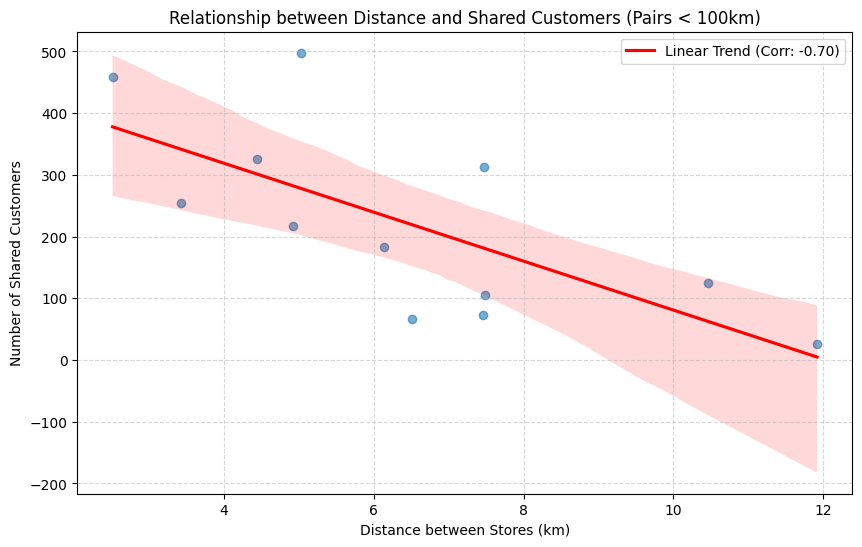

Correlation between Distance and Shared Customers: -0.70


In [19]:
# 4. correlation analytic
plt.figure(figsize=(10, 6))

# distance (set life circle in 100km)
data_filtered = df_adjacency[df_adjacency['distance_km'] < 100]

# calculate correlation
corr = data_filtered[['distance_km', 'shared_customers']].corr().iloc[0,1]

sns.regplot(
    data=data_filtered, 
    x='distance_km', 
    y='shared_customers', 
    scatter_kws={'alpha': 0.6}, 
    line_kws={'color': 'red', 'label': f'Linear Trend (Corr: {corr:.2f})'}
)


plt.title(f'Relationship between Distance and Shared Customers (Pairs < 100km)')
plt.xlabel('Distance between Stores (km)')
plt.ylabel('Number of Shared Customers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend() 
plt.show()

print(f"Correlation between Distance and Shared Customers: {corr:.2f}")

### 4. Geographic Network Visualization (< 50km Radius)
**Objective:** Map the intensity of customer overlap. Stores within a 50km radius with shared customers are connected via network lines, where the line thickness represents the volume of shared shoppers.

In [20]:
limit_km = 50

connected_pairs_50km = df_adjacency[
    (df_adjacency['shared_customers'] > 0) & 
    (df_adjacency['distance_km'] < limit_km)
].sort_values(by='shared_customers', ascending=False)

display_cols = ['Store_Name_A', 'Store_Name_B', 'distance_km', 'shared_customers']
print(f"Top connected pairs (Distance < {limit_km}km):")
display(connected_pairs_50km[display_cols].head(10))

print(f"\nDrawing Map for {len(connected_pairs_50km)} pairs under {limit_km}km...")

# Prepare Map Data
relevant_store_ids = set(connected_pairs_50km['ID_LIEU_DE_VENTE_A']).union(set(connected_pairs_50km['ID_LIEU_DE_VENTE_B']))

filtered_stores_list = []
for store_id in relevant_store_ids:
    if store_id in store_coords:
        store_data = store_coords[store_id].copy()
        store_data['ID'] = store_id
        store_data['NAME'] = store_names.get(store_id, f"Store {store_id}")
        filtered_stores_list.append(store_data)

# boundary
lats = [s['LATITUDE'] for s in filtered_stores_list]
lons = [s['LONGITUDE'] for s in filtered_stores_list]

if lats and lons:
    min_lat, max_lat = min(lats), max(lats)
    min_lon, max_lon = min(lons), max(lons)
else:
    min_lat, max_lat = 42.0, 51.0
    min_lon, max_lon = -5.0, 8.0


Top connected pairs (Distance < 50km):


,Store_Name_A,Store_Name_B,distance_km,shared_customers
8,Meyzieu,Decines,5.031330,498
14,Decines,Bron,2.516465,459
2,Vaulx en Velin,Decines,4.441077,326
5,Perpignan,Polygone,7.467344,312
11,Wasquehal,Hem,3.430526,255
0,Vaulx en Velin,Meyzieu,4.919140,217
13,Mions,Bron,6.142806,183
7,Meyzieu,Mions,10.463365,125
12,Mions,Decines,7.489141,105
9,Meyzieu,Bron,7.455485,73



Drawing Map for 12 pairs under 50km...


In [21]:
# Initialize Map
m = folium.Map(tiles='cartodbpositron') 
m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

# Draw Connection Lines
if not connected_pairs_50km.empty:
    max_weight = connected_pairs_50km['shared_customers'].max()

    for _, row in connected_pairs_50km.iterrows():
        loc_a = [store_coords[row['ID_LIEU_DE_VENTE_A']]['LATITUDE'], store_coords[row['ID_LIEU_DE_VENTE_A']]['LONGITUDE']]
        loc_b = [store_coords[row['ID_LIEU_DE_VENTE_B']]['LATITUDE'], store_coords[row['ID_LIEU_DE_VENTE_B']]['LONGITUDE']]
        
        folium.PolyLine(
            locations=[loc_a, loc_b],
            weight=(row['shared_customers'] / max_weight) * 5 + 1, 
            color='#E74C3C',
            opacity=0.6,
            tooltip=f"{row['Store_Name_A']} <-> {row['Store_Name_B']}<br>Shared: {row['shared_customers']}<br>Dist: {row['distance_km']:.1f}km"
        ).add_to(m)

# Draw Store Markers
for store in filtered_stores_list:
    folium.CircleMarker(
        location=[store['LATITUDE'], store['LONGITUDE']],
        radius=6,
        color='#2980B9', 
        fill=True,
        fill_color='#2980B9',
        popup=f"{store['NAME']} (ID: {store['ID']})"
    ).add_to(m)
    
# show map
m

In [22]:
connected_pairs_50km

,ID_LIEU_DE_VENTE_A,ID_LIEU_DE_VENTE_B,shared_customers,distance_km,Store_Name_A,Store_Name_B
8,180,532,498,5.031330,Meyzieu,Decines
14,532,534,459,2.516465,Decines,Bron
2,106,532,326,4.441077,Vaulx en Velin,Decines
5,163,277,312,7.467344,Perpignan,Polygone
11,220,993,255,3.430526,Wasquehal,Hem
0,106,180,217,4.919140,Vaulx en Velin,Meyzieu
13,414,534,183,6.142806,Mions,Bron
7,180,414,125,10.463365,Meyzieu,Mions
12,414,532,105,7.489141,Mions,Decines
9,180,534,73,7.455485,Meyzieu,Bron


### 5. Cross-Store Basket Analysis (Cannibalization vs. Synergy)
**Objective:** Deep dive into specific store pairs to compare how shared customers allocate their wallet spend across different categories. This identifies whether adjacent stores are cannibalizing each other or serving complementary needs.

In [23]:
# definition: Cross-Store Basket Analysis
def analyze_pair(index):
    if index < 0 or index >= len(connected_pairs_50km):
        print(f"Error: Please enter number between 0 and {len(connected_pairs_50km)-1}.")
        return

    # 1. adjacent pairs store and number of shared customers
    target_pair = connected_pairs_50km.iloc[index]
    store_a_id = target_pair['ID_LIEU_DE_VENTE_A']
    store_b_id = target_pair['ID_LIEU_DE_VENTE_B']
    store_a_name = target_pair['Store_Name_A']
    store_b_name = target_pair['Store_Name_B']

    print(f"\n{'='*60}")
    print(f"Top {index + 1} Pair: {store_a_name} vs. {store_b_name}")
    print(f"{'='*60}")

    customers_a = set(df_transactions[df_transactions['ID_LIEU_DE_VENTE'] == store_a_id]['NO_TOKEN_CB'])
    customers_b = set(df_transactions[df_transactions['ID_LIEU_DE_VENTE'] == store_b_id]['NO_TOKEN_CB'])
    shared_customers = customers_a.intersection(customers_b)

    print(f"Number of shared customers analyzed: {len(shared_customers)}")

    # 2. filter: shared customer data in this two store
    df_shared_trx = df_transactions[
        (df_transactions['NO_TOKEN_CB'].isin(shared_customers)) &
        (df_transactions['ID_LIEU_DE_VENTE'].isin([store_a_id, store_b_id]))
    ]

    if df_shared_trx.empty:
        print("No shared customers transaction record.")
        return

    # 3. calculate total spend for percentage
    category_col = 'LB_SOUS_RAYON' 
    spend_by_cat = df_shared_trx.groupby(['ID_LIEU_DE_VENTE', category_col])['MT_TTC_NET'].sum().reset_index()

    total_spend_a = spend_by_cat[spend_by_cat['ID_LIEU_DE_VENTE'] == store_a_id]['MT_TTC_NET'].sum()
    total_spend_b = spend_by_cat[spend_by_cat['ID_LIEU_DE_VENTE'] == store_b_id]['MT_TTC_NET'].sum()

    spend_by_cat['Spend_Pct'] = np.where(
        spend_by_cat['ID_LIEU_DE_VENTE'] == store_a_id,
        (spend_by_cat['MT_TTC_NET'] / total_spend_a) * 100,
        (spend_by_cat['MT_TTC_NET'] / total_spend_b) * 100
    )

    # 4. visulization
    pivot_df = spend_by_cat.pivot(index=category_col, columns='ID_LIEU_DE_VENTE', values='Spend_Pct').fillna(0)
    pivot_df.columns = [store_a_name, store_b_name] 

    pivot_df['Total'] = pivot_df[store_a_name] + pivot_df[store_b_name]
    pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns=['Total']).head(10)

    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_df.plot(kind='bar', width=0.7, color=['#3498DB', '#E74C3C'], edgecolor='black', ax=ax)

    plt.title(f'Shopping Basket Comparison (Shared Customers)\n{store_a_name} vs {store_b_name}', fontsize=14, fontweight='bold')
    plt.ylabel('% of Wallet Spend in Store', fontsize=12)
    plt.xlabel(f'Product Category ({category_col})', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Store')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 5. analyze Complementary goods
    pivot_df['Difference (Abs %)'] = abs(pivot_df[store_a_name] - pivot_df[store_b_name])
    print("\n--- Categories with the Biggest Difference (Complementary Behavior) ---")
    display(pivot_df.sort_values(by='Difference (Abs %)', ascending=False).head(5))


Top 1 Pair: Meyzieu vs. Decines
Number of shared customers analyzed: 498


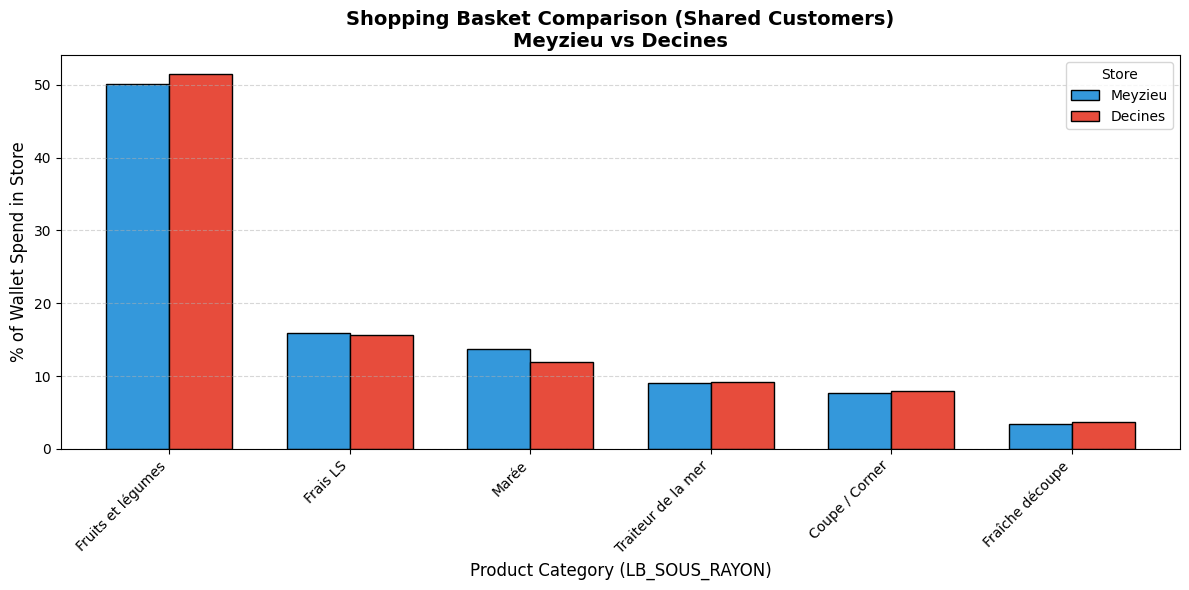


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Meyzieu,Decines,Difference (Abs %)
LB_SOUS_RAYON,,,
Marée,13.751034,11.885507,1.865527
Fruits et légumes,50.127978,51.472422,1.344444
Coupe / Corner,7.710490,8.016599,0.306109
Fraîche découpe,3.480069,3.744011,0.263942
Frais LS,15.919851,15.664669,0.255182



Top 2 Pair: Decines vs. Bron
Number of shared customers analyzed: 459


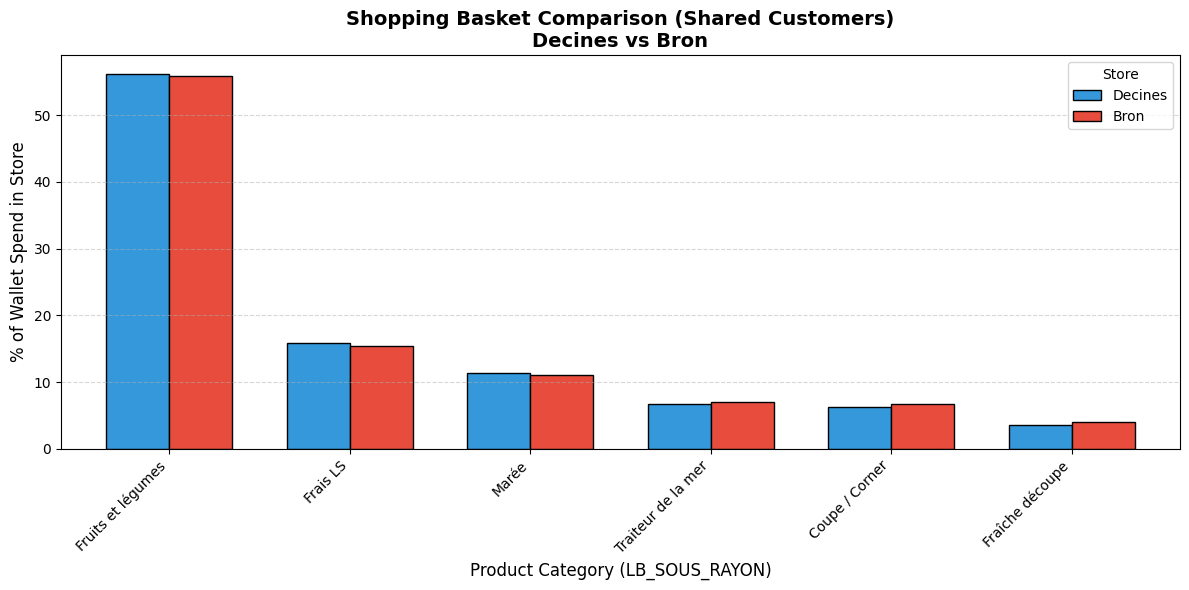


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Decines,Bron,Difference (Abs %)
LB_SOUS_RAYON,,,
Frais LS,15.808617,15.361571,0.447046
Fraîche découpe,3.639169,4.055726,0.416556
Coupe / Corner,6.342497,6.669450,0.326953
Fruits et légumes,56.137990,55.820459,0.317531
Traiteur de la mer,6.748319,7.056871,0.308553



Top 3 Pair: Vaulx en Velin vs. Decines
Number of shared customers analyzed: 326


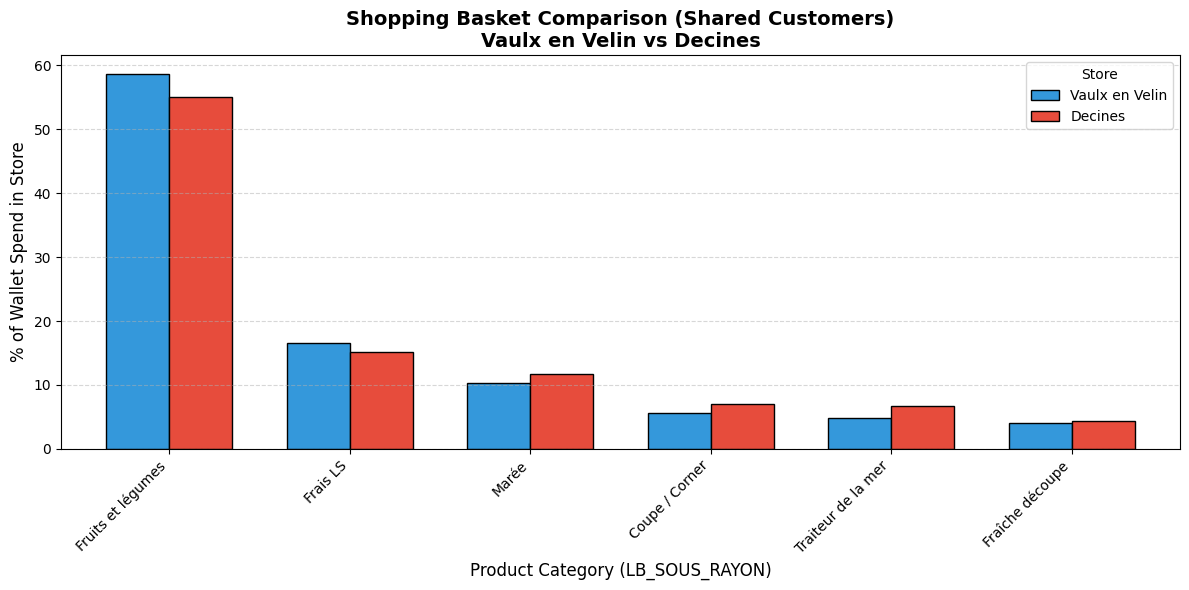


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Vaulx en Velin,Decines,Difference (Abs %)
LB_SOUS_RAYON,,,
Fruits et légumes,58.654223,55.117275,3.536948
Traiteur de la mer,4.865812,6.688871,1.823059
Marée,10.263078,11.676153,1.413075
Coupe / Corner,5.598881,6.980652,1.381771
Frais LS,16.554423,15.205988,1.348435


In [24]:
# Lyon
analyze_pair(0)
analyze_pair(1)
analyze_pair(2)


Top 4 Pair: Perpignan vs. Polygone
Number of shared customers analyzed: 312


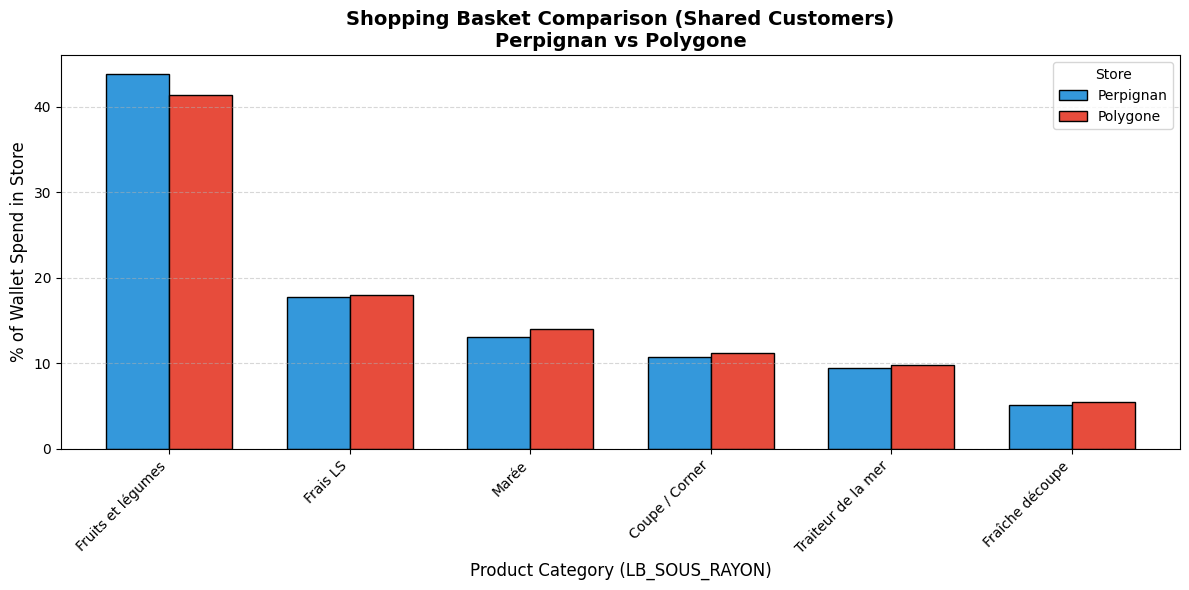


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Perpignan,Polygone,Difference (Abs %)
LB_SOUS_RAYON,,,
Fruits et légumes,43.838149,41.440479,2.397670
Marée,13.106781,14.063900,0.957118
Coupe / Corner,10.700213,11.261579,0.561366
Fraîche découpe,5.112413,5.494838,0.382426
Traiteur de la mer,9.485314,9.774775,0.289462


In [25]:
# Perpignan
analyze_pair(3)


Top 5 Pair: Wasquehal vs. Hem
Number of shared customers analyzed: 255


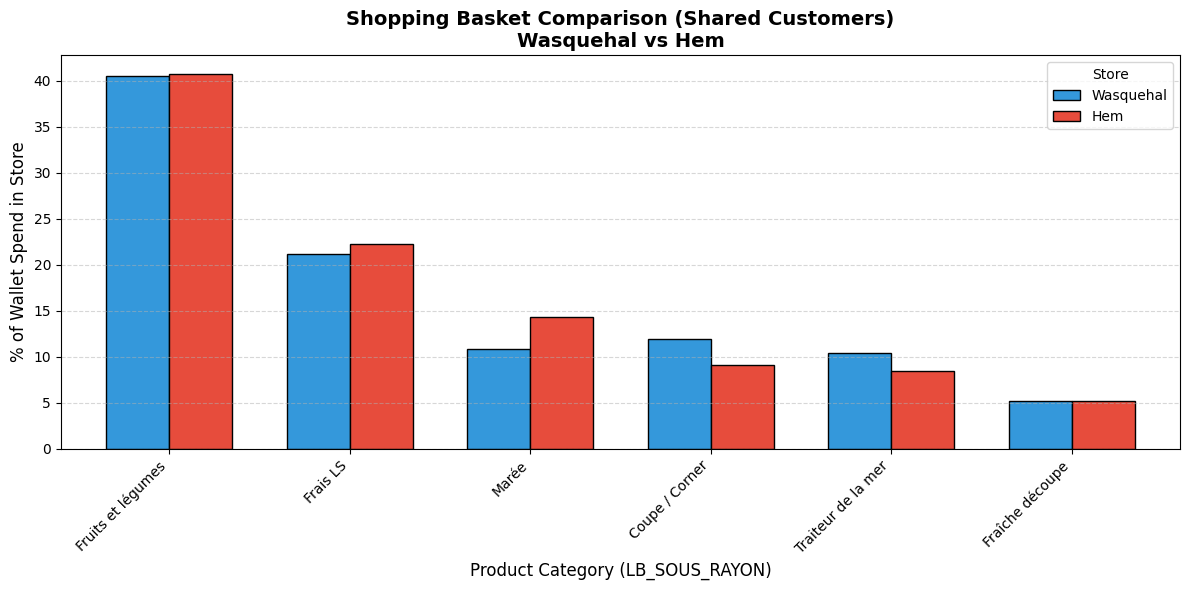


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Wasquehal,Hem,Difference (Abs %)
LB_SOUS_RAYON,,,
Marée,10.824391,14.277954,3.453563
Coupe / Corner,11.891023,9.161458,2.729565
Traiteur de la mer,10.427681,8.405706,2.021975
Frais LS,21.216932,22.243689,1.026757
Fruits et légumes,40.485114,40.714495,0.229381


In [26]:
# lille
analyze_pair(4)


Top 6 Pair: Vaulx en Velin vs. Meyzieu
Number of shared customers analyzed: 217


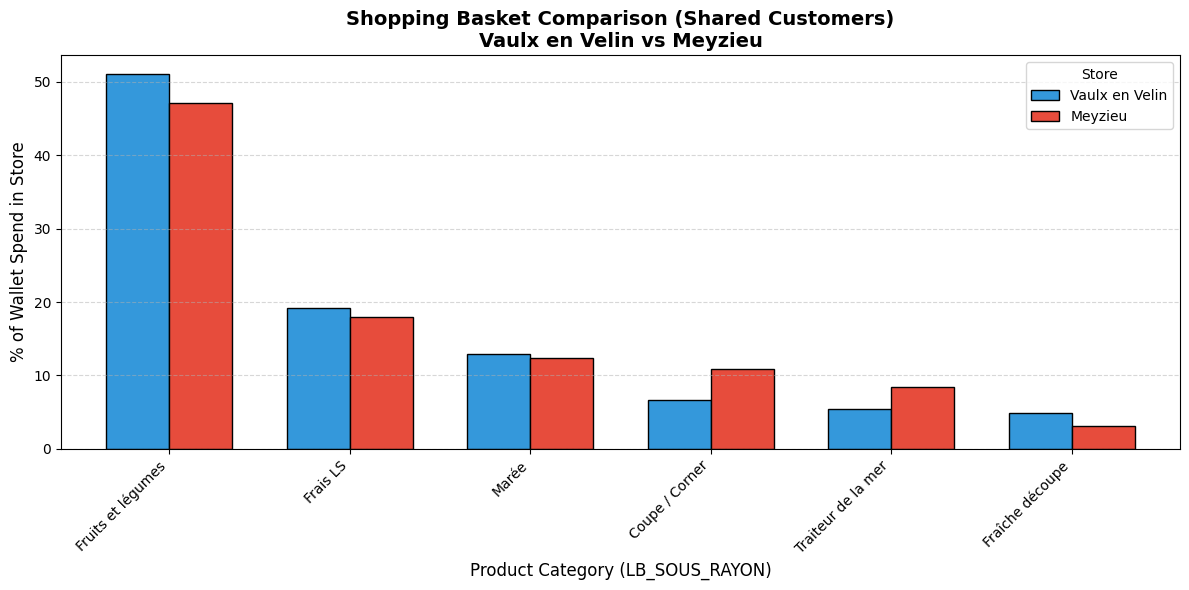


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Vaulx en Velin,Meyzieu,Difference (Abs %)
LB_SOUS_RAYON,,,
Coupe / Corner,6.608372,10.913645,4.305272
Fruits et légumes,51.054946,47.127913,3.927034
Traiteur de la mer,5.381012,8.405360,3.024349
Fraîche découpe,4.941041,3.174488,1.766553
Frais LS,19.130453,18.012157,1.118296



Top 7 Pair: Mions vs. Bron
Number of shared customers analyzed: 183


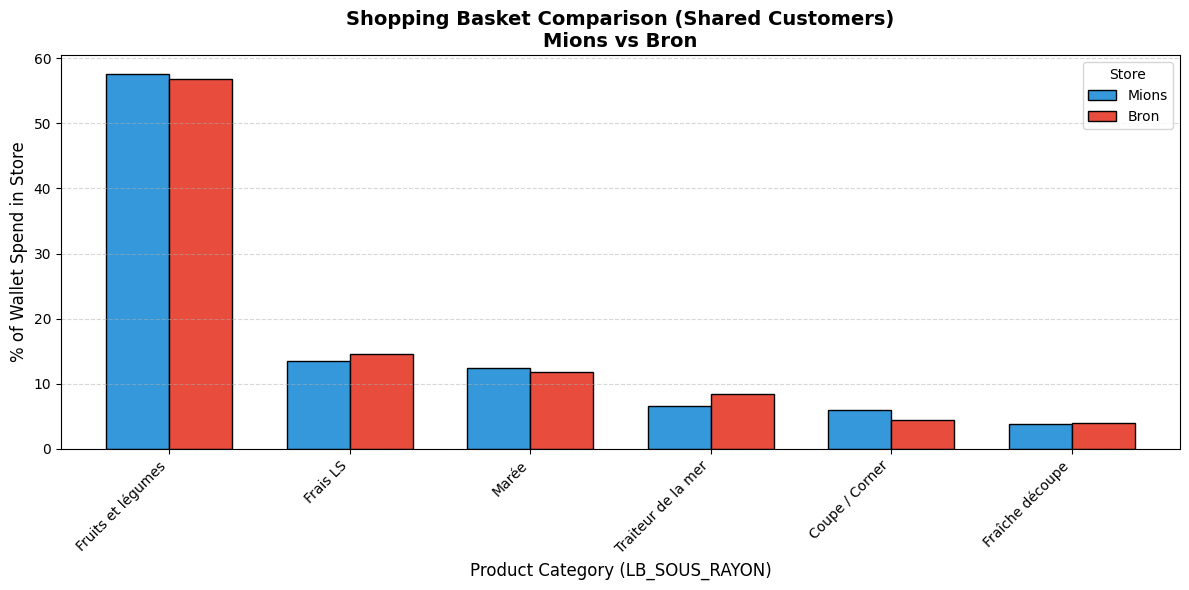


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Mions,Bron,Difference (Abs %)
LB_SOUS_RAYON,,,
Traiteur de la mer,6.629640,8.362074,1.732434
Coupe / Corner,5.936081,4.390846,1.545235
Frais LS,13.502353,14.572522,1.070169
Fruits et légumes,57.566617,56.850374,0.716243
Marée,12.470111,11.843686,0.626425



Top 8 Pair: Meyzieu vs. Mions
Number of shared customers analyzed: 125


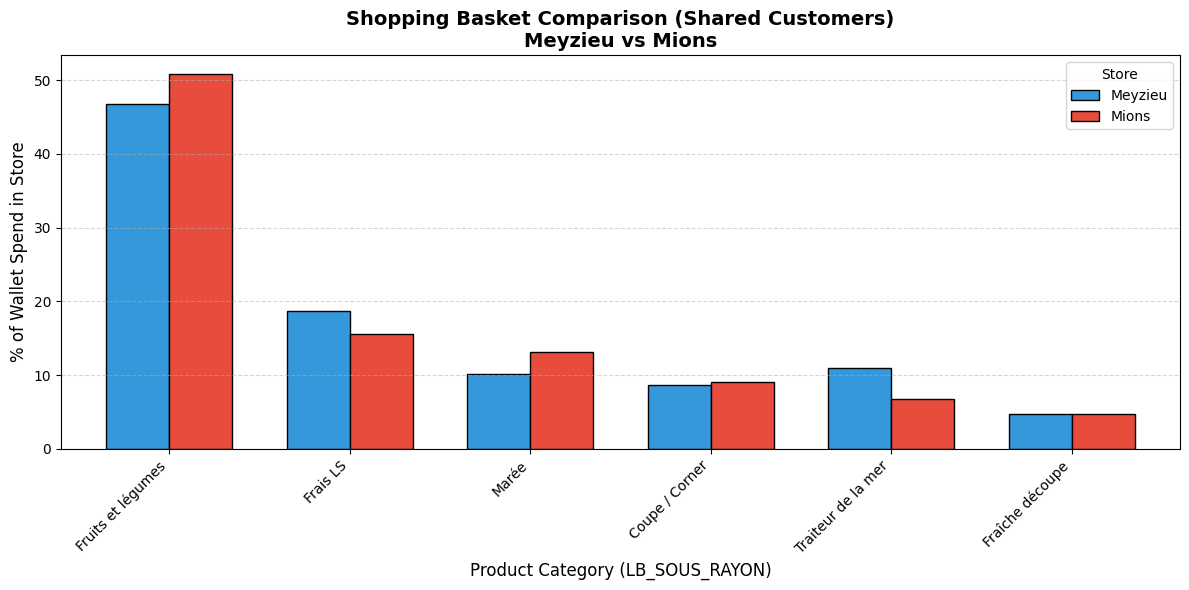


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Meyzieu,Mions,Difference (Abs %)
LB_SOUS_RAYON,,,
Traiteur de la mer,10.932598,6.704056,4.228542
Fruits et légumes,46.803726,50.834314,4.030588
Frais LS,18.673438,15.525714,3.147725
Marée,10.179829,13.163676,2.983847
Coupe / Corner,8.666479,9.038569,0.372090



Top 9 Pair: Mions vs. Decines
Number of shared customers analyzed: 105


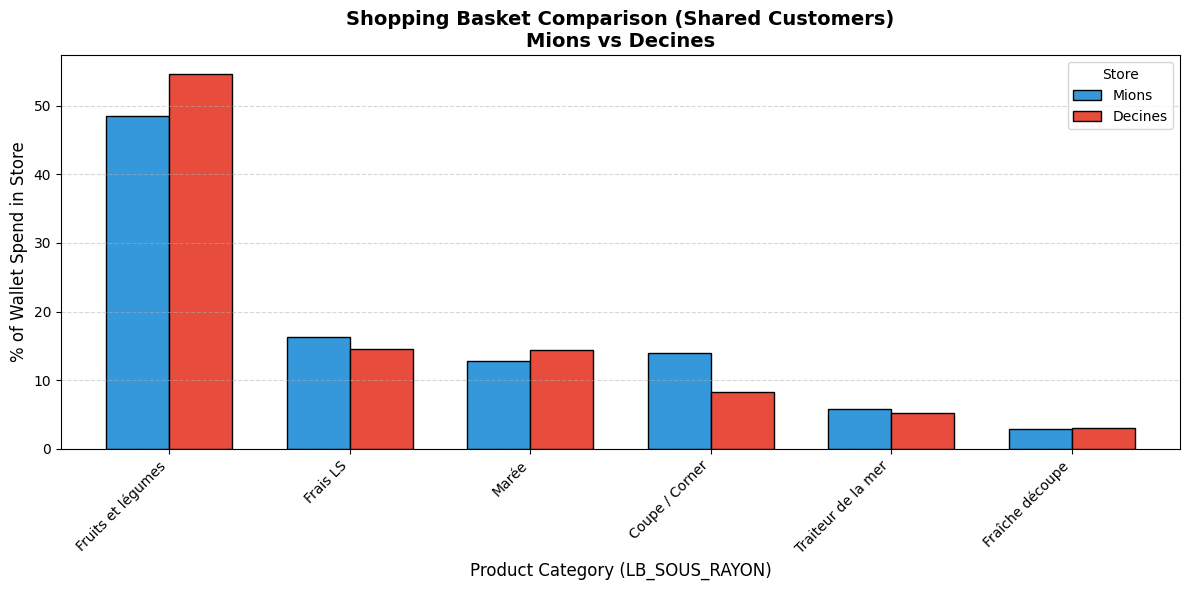


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Mions,Decines,Difference (Abs %)
LB_SOUS_RAYON,,,
Fruits et légumes,48.432249,54.585555,6.153306
Coupe / Corner,13.902473,8.288907,5.613566
Frais LS,16.258629,14.539101,1.719527
Marée,12.727666,14.337504,1.609838
Traiteur de la mer,5.849383,5.168118,0.681265



Top 10 Pair: Meyzieu vs. Bron
Number of shared customers analyzed: 73


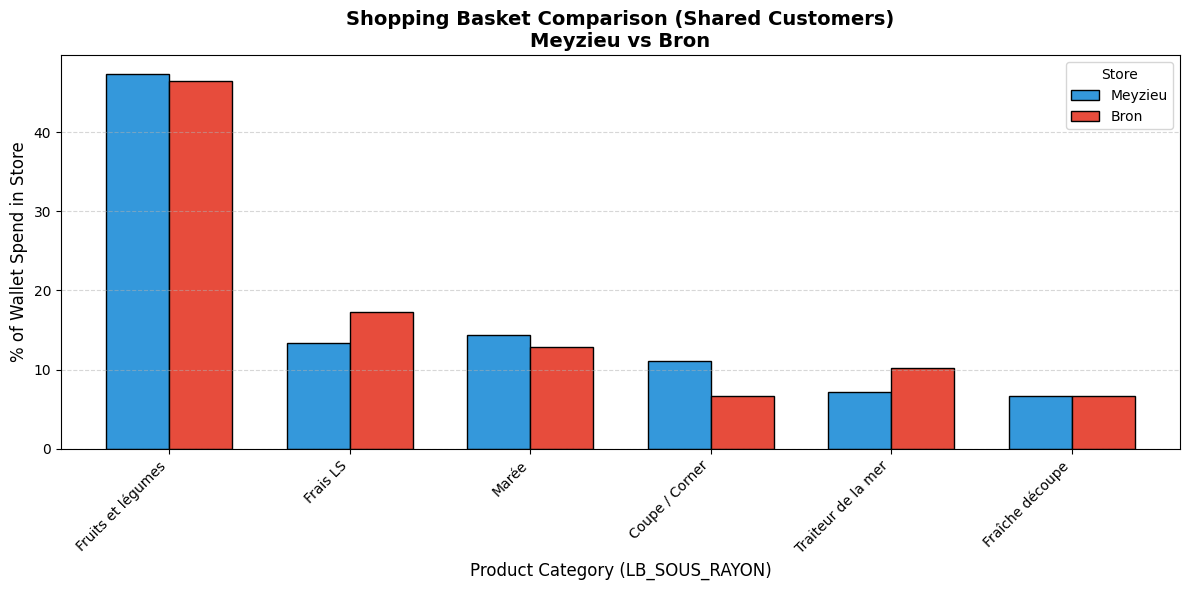


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Meyzieu,Bron,Difference (Abs %)
LB_SOUS_RAYON,,,
Coupe / Corner,11.051557,6.658393,4.393164
Frais LS,13.392043,17.246953,3.854910
Traiteur de la mer,7.136346,10.154193,3.017846
Marée,14.368591,12.857389,1.511202
Fruits et légumes,47.324820,46.457009,0.867811



Top 11 Pair: Vaulx en Velin vs. Bron
Number of shared customers analyzed: 67


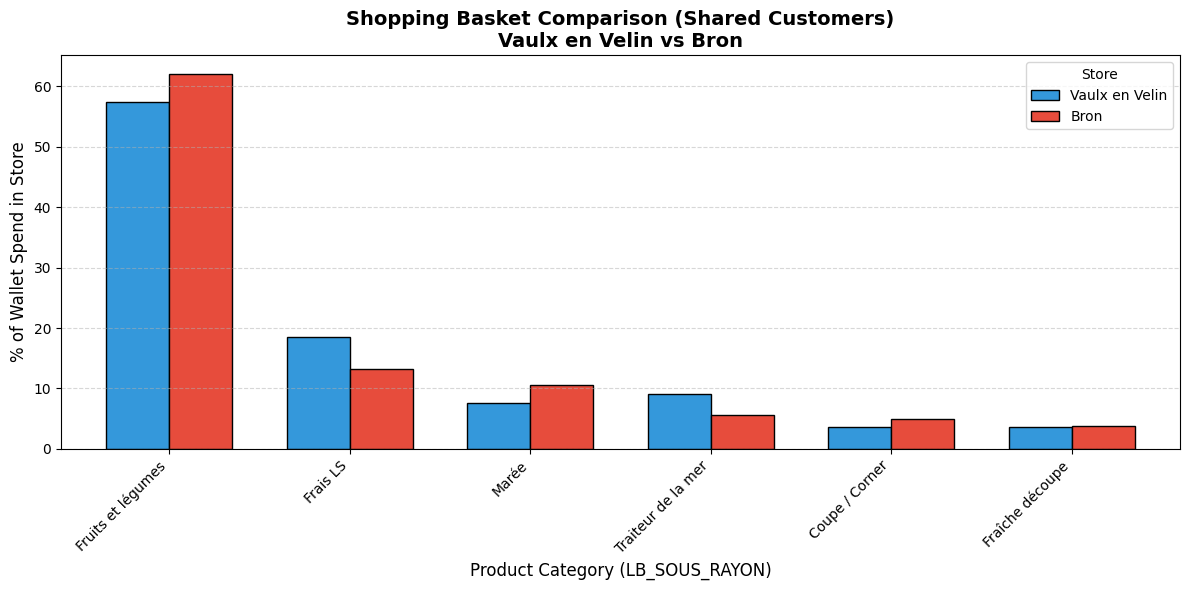


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Vaulx en Velin,Bron,Difference (Abs %)
LB_SOUS_RAYON,,,
Frais LS,18.484818,13.159388,5.325430
Fruits et légumes,57.471840,62.028240,4.556399
Traiteur de la mer,9.101331,5.610243,3.491088
Marée,7.636014,10.494437,2.858424
Coupe / Corner,3.631294,4.951222,1.319927



Top 12 Pair: Vaulx en Velin vs. Mions
Number of shared customers analyzed: 26


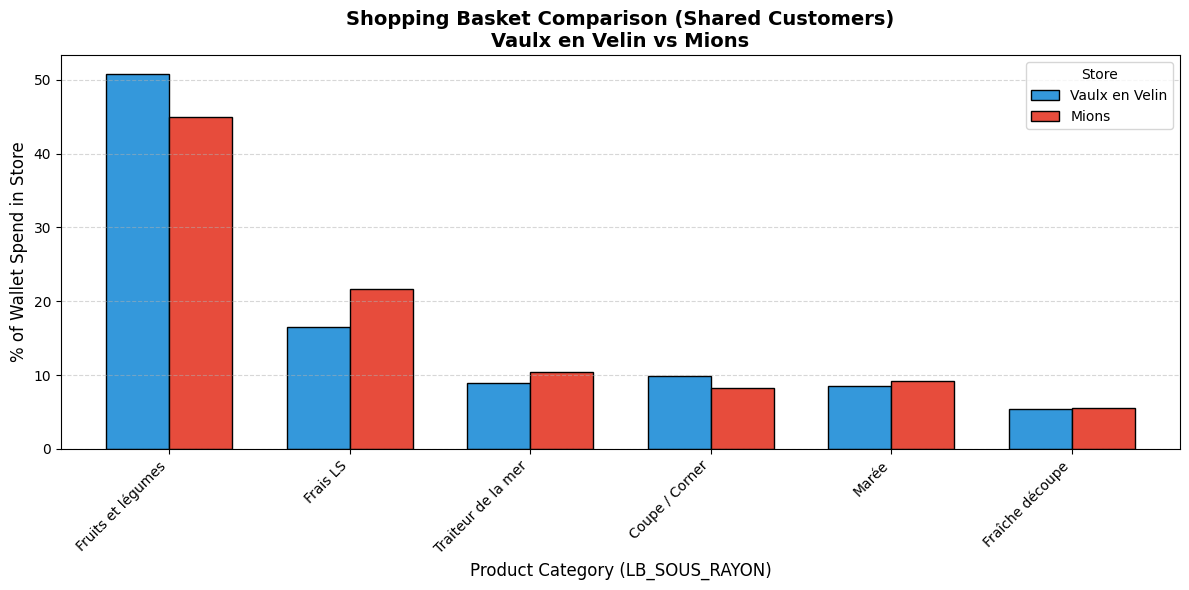


--- Categories with the Biggest Difference (Complementary Behavior) ---


,Vaulx en Velin,Mions,Difference (Abs %)
LB_SOUS_RAYON,,,
Fruits et légumes,50.770295,44.936992,5.833303
Frais LS,16.575489,21.665051,5.089562
Coupe / Corner,9.805278,8.204086,1.601192
Traiteur de la mer,8.922845,10.454105,1.531260
Marée,8.556038,9.136157,0.580119


In [27]:
analyze_pair(5)
analyze_pair(6)
analyze_pair(7)
analyze_pair(8)
analyze_pair(9)
analyze_pair(10)
analyze_pair(11)


## Phase 3: Regional Profiling & Product Mix

### 6. Regional Purchasing Power Analysis
**Objective:** Map postal codes to broader French regions and calculate key macro-level indicators: Average Transaction Value (ATV) and Average Basket Size (ABS) by region.

In [28]:
# postal code list
unique_depts = df_transactions['CD_POSTAL'].astype(str).str[:2].unique()
print("all postal code in dataset：")
print(sorted(unique_depts))

all postal code in dataset：
['14', '59', '66', '67', '69']


In [29]:
# 1. Mapping Regions
region_mapping = {
    '14': 'Normandie (NW)',
    '59': 'Hauts-de-France (N)',
    '66': 'Occitanie (S)',
    '67': 'Grand Est (E)',
    '69': 'Auvergne-Rhône-Alpes (Central)'
}

df_transactions['Region'] = df_transactions['CD_POSTAL'].astype(str).str[:2].map(region_mapping)

print("Append Region column！\nTransaction number in each region：")
display(df_transactions['Region'].value_counts())

Append Region column！
Transaction number in each region：


Region
Auvergne-Rhône-Alpes (Central)    688084
Hauts-de-France (N)               206830
Occitanie (S)                     198371
Grand Est (E)                     115371
Normandie (NW)                     95690
Name: count, dtype: int64


--- Regional Purchasing Power ---


,Region,Avg_Transaction_Value,Avg_Basket_Size
4,Occitanie (S),32.11,9.03
1,Grand Est (E),28.46,8.81
3,Normandie (NW),26.95,8.14
2,Hauts-de-France (N),26.71,8.07
0,Auvergne-Rhône-Alpes (Central),26.07,7.94


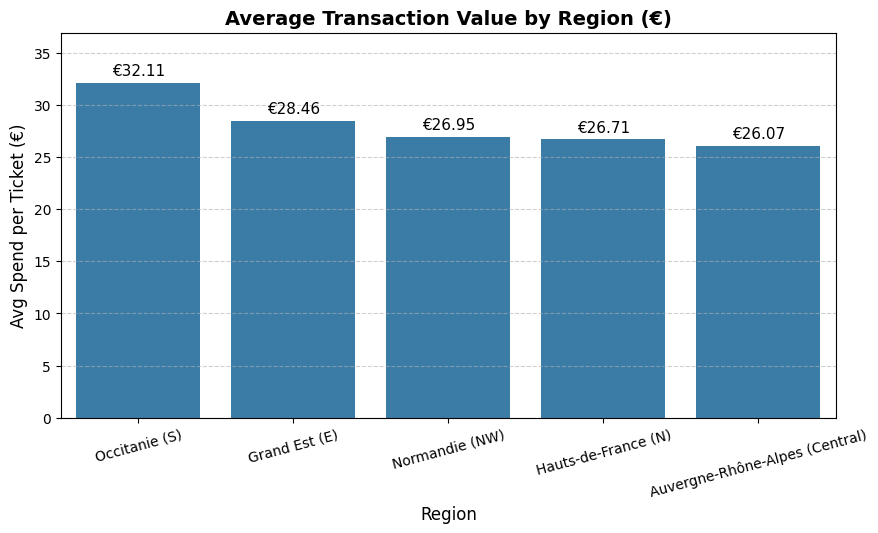

In [30]:
# Regional Purchasing Power
# ==========================================
print("\n--- Regional Purchasing Power ---")

order_level = df_transactions.groupby(['Region', 'CD_TICKET_UNIQUE']).agg(
    Order_Total_Spend=('MT_TTC_NET', 'sum'),
    Order_Total_Items=('QT_UVC', 'sum') 
).reset_index()

# Avg_Transaction_Value and Avg_Basket_Size
regional_kpi = order_level.groupby('Region').agg(
    Avg_Transaction_Value=('Order_Total_Spend', 'mean'),
    Avg_Basket_Size=('Order_Total_Items', 'mean')
).reset_index().sort_values(by='Avg_Transaction_Value', ascending=False)

display(regional_kpi.round(2))

# visualization
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=regional_kpi, 
    x='Region', 
    y='Avg_Transaction_Value',
    color='#2980B9' 
)

ax.bar_label(ax.containers[0], fmt='€%.2f', padding=3, fontsize=11)

plt.title('Average Transaction Value by Region (€)', fontsize=14, fontweight='bold')
plt.ylabel('Avg Spend per Ticket (€)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

max_value = regional_kpi['Avg_Transaction_Value'].max()
plt.ylim(0, max_value * 1.15) 

plt.show()

### 7. Regional Category Preferences (METIER & FAMILLE)
**Objective:** Visualize regional shopping preferences using heatmaps to identify which broad departments (METIER) and specific product families (FAMILLE) dominate local wallets.

In [31]:
def get_category_pivot(df, category_col, top_n=12):
    # 1. calculate sale amount
    reg_cat_sales = df.groupby(['Region', category_col])['MT_TTC_NET'].sum().reset_index()
    # 2. total sale amount
    reg_total = reg_cat_sales.groupby('Region')['MT_TTC_NET'].sum().reset_index(name='Region_Total')
    # 3. percentage
    reg_cat_sales = reg_cat_sales.merge(reg_total, on='Region')
    reg_cat_sales['Spend_Pct'] = (reg_cat_sales['MT_TTC_NET'] / reg_cat_sales['Region_Total']) * 100
    # 4. Pivot Table
    pivot_reg = reg_cat_sales.pivot(index=category_col, columns='Region', values='Spend_Pct').fillna(0)
    # 5. top
    pivot_reg['Global_Score'] = pivot_reg.sum(axis=1)
    return pivot_reg.sort_values(by='Global_Score', ascending=False).head(top_n).drop(columns=['Global_Score'])
    

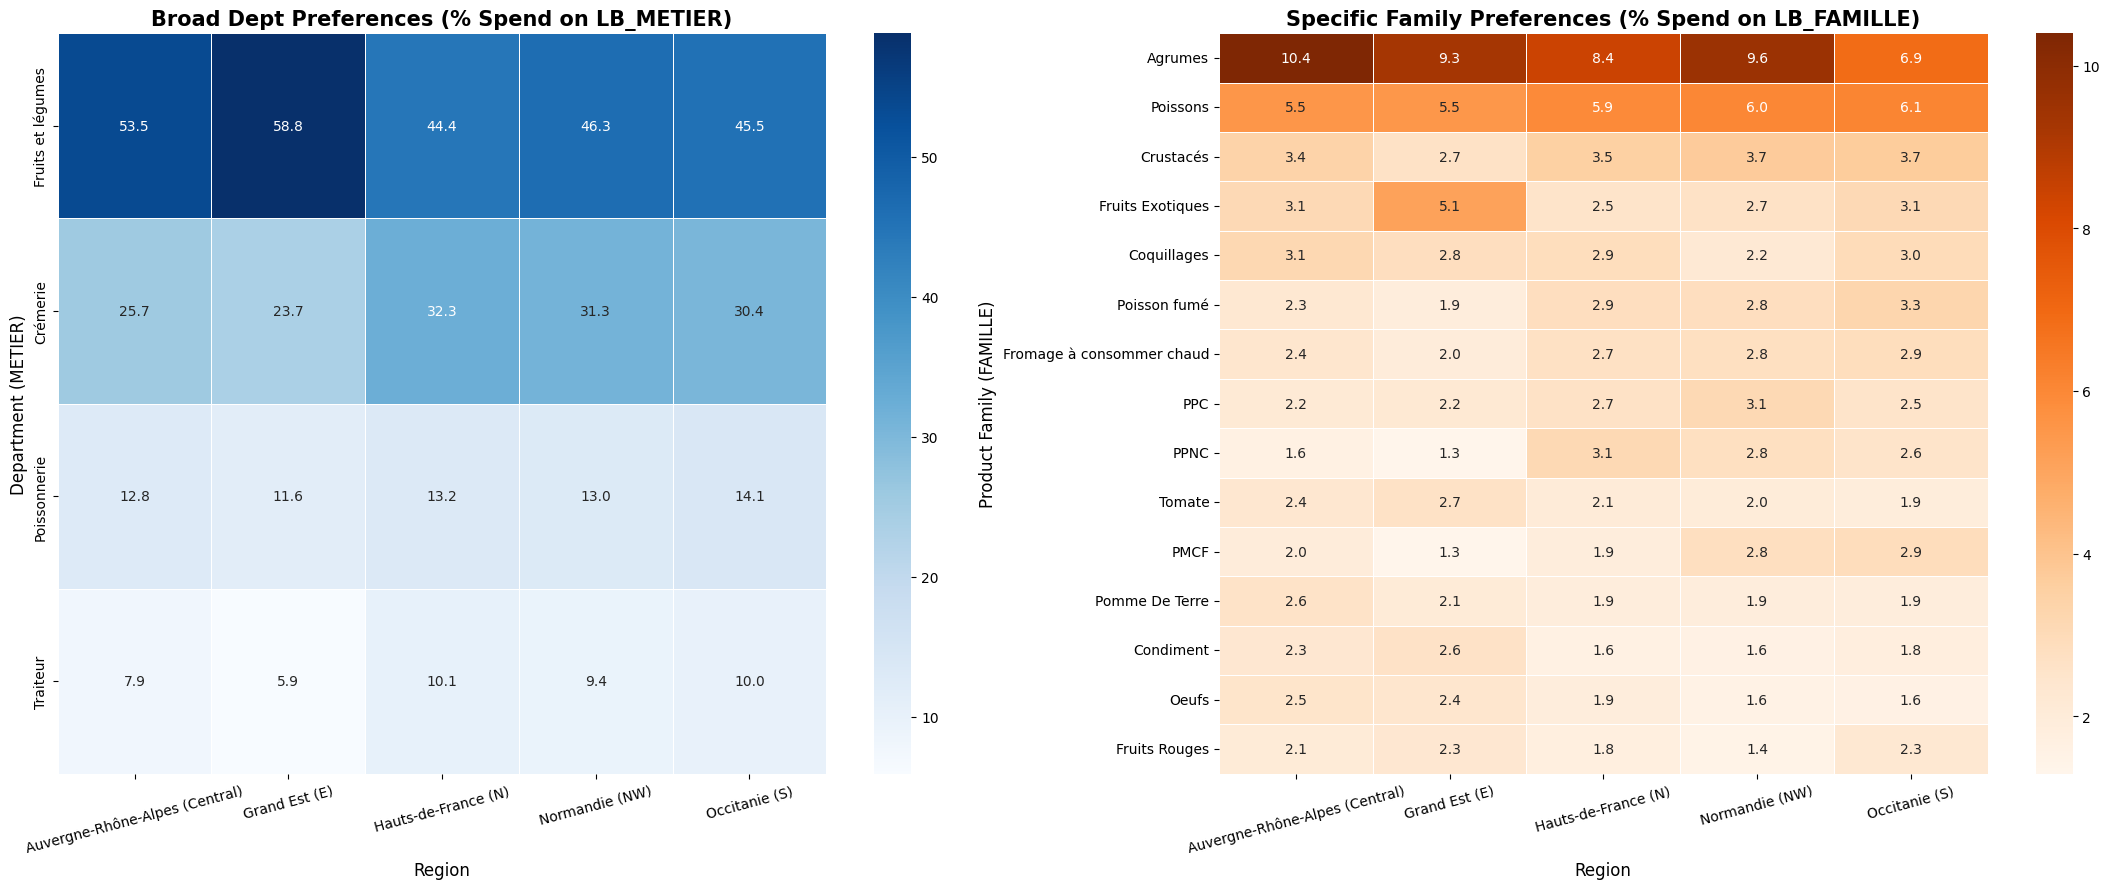

In [32]:
top_metier = get_category_pivot(df_transactions, 'LB_METIER')
top_famille = get_category_pivot(df_transactions, 'LB_FAMILLE', top_n=15)

# visualization
fig, axes = plt.subplots(1, 2, figsize=(22, 9)) 

# LB_METIER 
sns.heatmap(top_metier, annot=True, fmt=".1f", cmap="Blues", linewidths=.5, ax=axes[0])
axes[0].set_title('Broad Dept Preferences (% Spend on LB_METIER)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Department (METIER)', fontsize=12)
axes[0].set_xlabel('Region', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# LB_FAMILLE 
sns.heatmap(top_famille, annot=True, fmt=".1f", cmap="Oranges", linewidths=.5, ax=axes[1])
axes[1].set_title('Specific Family Preferences (% Spend on LB_FAMILLE)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Product Family (FAMILLE)', fontsize=12)
axes[1].set_xlabel('Region', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 8. Regional Promotional Dependency vs. Sales Contribution
**Objective:** Contrast pure sales contribution with promotional reliance. This reveals "False Prosperity"—categories that generate high revenue but are dangerously dependent on price discounts.

In [33]:
# 1. promo tag
df_transactions['IS_PROMO_ANY'] = np.where(
    (df_transactions['IS_PROMO_NATIONALE'] == 1) | (df_transactions['IS_PROMO_MAGASIN'] == 1), 
    1, 0
)


In [34]:
# 2. def calculate Total_Sales pct & promo sensitivity
def get_combined_pivots(df, category_col, top_n=12):
    grp = df.groupby(['Region', category_col]).apply(
        lambda x: pd.Series({
            'Total_Sales': x['MT_TTC_NET'].sum(),
            'Promo_Sales': x.loc[x['IS_PROMO_ANY'] == 1, 'MT_TTC_NET'].sum()
        })
    ).reset_index()
    
    reg_total = grp.groupby('Region')['Total_Sales'].sum().reset_index(name='Region_Total')
    grp = grp.merge(reg_total, on='Region')
    

    grp['Spend_Pct'] = (grp['Total_Sales'] / grp['Region_Total']) * 100
    
    # Promo_Share_Pct
    grp['Promo_Share_Pct'] = np.where(
        grp['Total_Sales'] == 0, 
        0, 
        (grp['Promo_Sales'] / grp['Total_Sales']) * 100
    )
    
    # Pivot Tables
    pivot_spend = grp.pivot(index=category_col, columns='Region', values='Spend_Pct').fillna(0)
    pivot_promo = grp.pivot(index=category_col, columns='Region', values='Promo_Share_Pct').fillna(0)
    
    pivot_spend['Global_Score'] = pivot_spend.sum(axis=1)
    top_cats = pivot_spend.sort_values(by='Global_Score', ascending=False).head(top_n).index
    
    pivot_spend = pivot_spend.loc[top_cats].drop(columns=['Global_Score'])
    pivot_promo = pivot_promo.loc[top_cats]
    
    return pivot_spend, pivot_promo


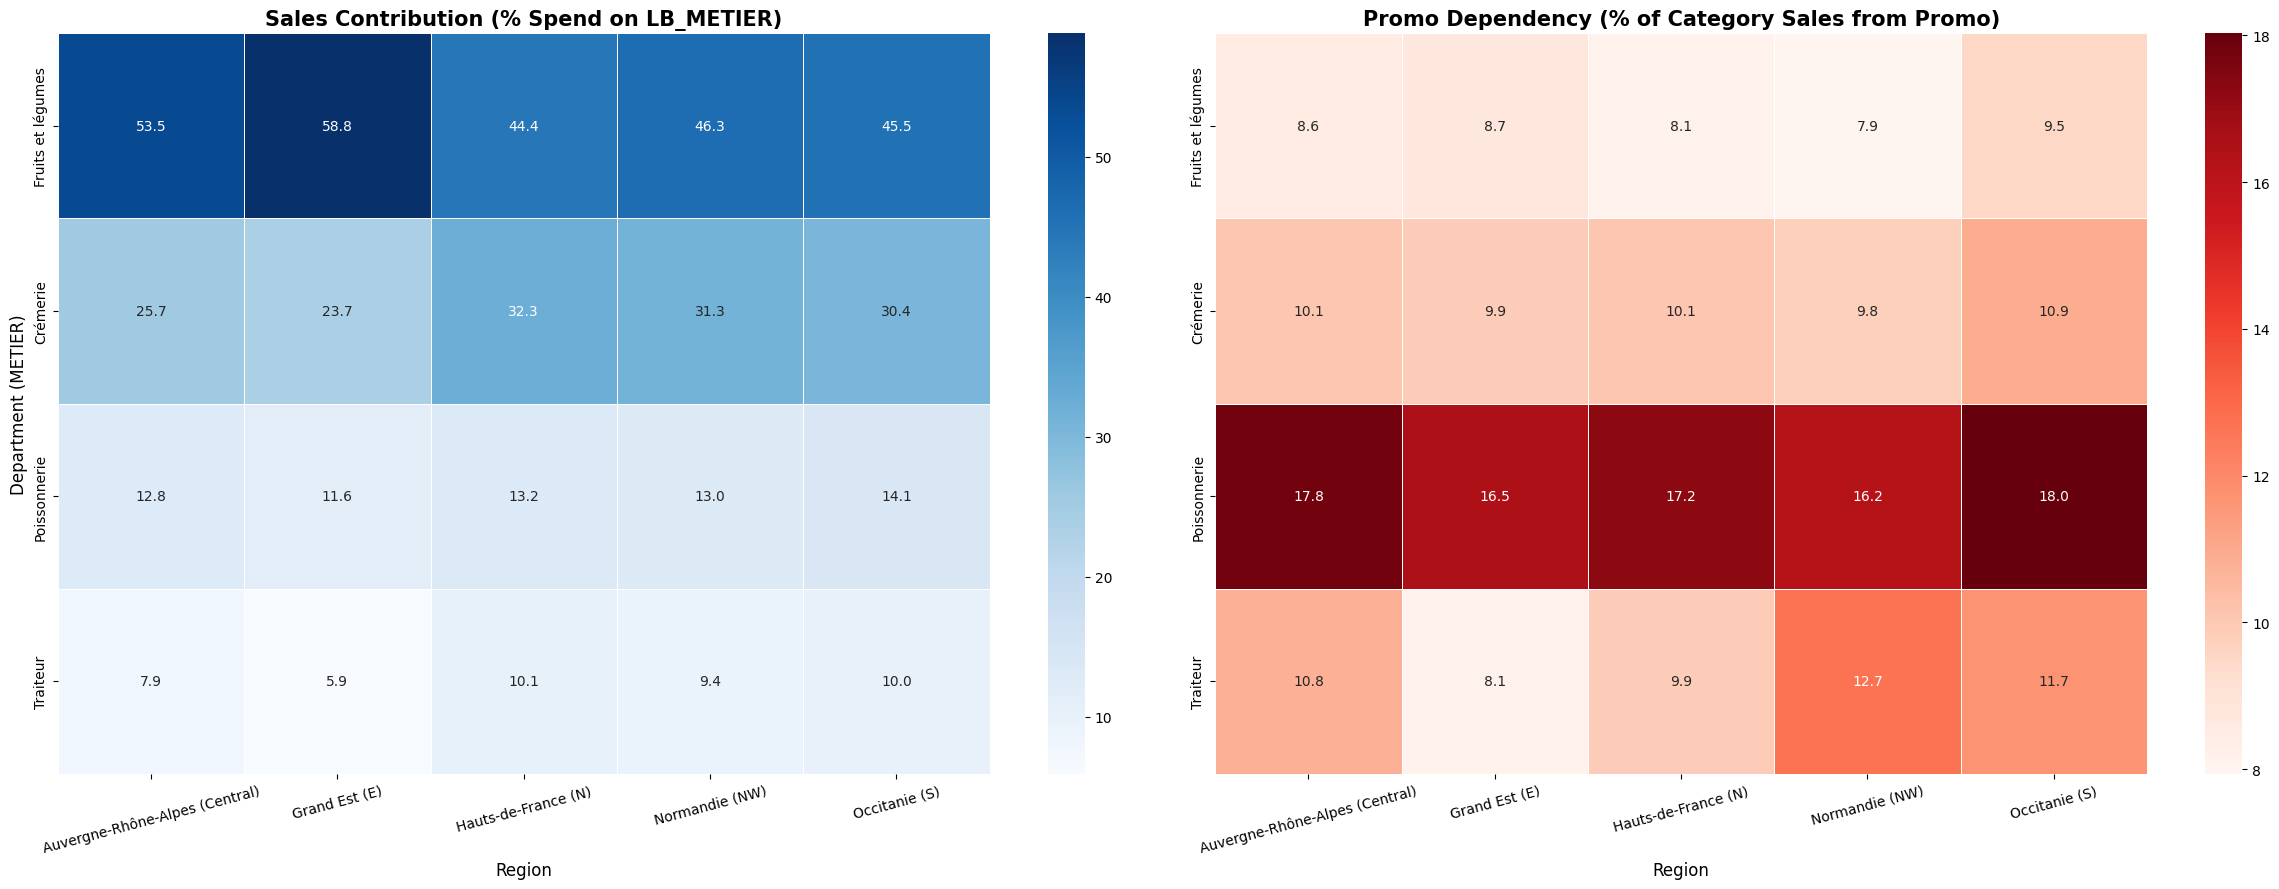

In [35]:
# 3. Pivot Tables
spend_metier, promo_metier = get_combined_pivots(df_transactions, 'LB_METIER', top_n=12)

# 4. visualize
fig, axes = plt.subplots(1, 2, figsize=(24, 9)) 

# left: region sales contribution
sns.heatmap(spend_metier, annot=True, fmt=".1f", cmap="Blues", linewidths=.5, ax=axes[0])
axes[0].set_title('Sales Contribution (% Spend on LB_METIER)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Department (METIER)', fontsize=12)
axes[0].set_xlabel('Region', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# right: promo dependency
sns.heatmap(promo_metier, annot=True, fmt=".1f", cmap="Reds", linewidths=.5, ax=axes[1])
axes[1].set_title('Promo Dependency (% of Category Sales from Promo)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Region', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 9. Product Mix Validation: Volume vs. Value Drivers
**Objective:** Validate business intuition regarding the Product Mix. By calculating Average Units per Ticket vs. Average Price per Unit, we isolate categories that drive basket depth (Volume Drivers, e.g., Produce) versus basket value (Value Drivers, e.g., Seafood).

In [36]:
qty_col = 'QT_UVC' 

# 1. Calculate the number of 'units' purchased per ticket in each department (METIER)
ticket_items = df_transactions.groupby(['CD_TICKET_UNIQUE', 'LB_METIER'])[qty_col].sum().reset_index()

# 2. Calculate the "Average Units per Ticket" for each department
dept_avg_units = ticket_items.groupby('LB_METIER')[qty_col].mean().reset_index()
dept_avg_units.rename(columns={qty_col: 'Avg_Units_per_Ticket'}, inplace=True)

# 3. Calculate the "Average Price per Unit" for each department
# First, calculate the total revenue and total units for each department
dept_totals = df_transactions.groupby('LB_METIER').agg(
    Total_Revenue=('MT_TTC_NET', 'sum'),
    Total_Units=(qty_col, 'sum')
).reset_index()

# Divide total revenue by total units to get the average price per unit
dept_totals['Avg_Price_per_Unit(€)'] = dept_totals['Total_Revenue'] / dept_totals['Total_Units']

# 4. Merge the data and sort (descending by average units per ticket)
product_mix_stats = pd.merge(dept_avg_units, dept_totals[['LB_METIER', 'Avg_Price_per_Unit(€)']], on='LB_METIER')
product_mix_stats = product_mix_stats.sort_values(by='Avg_Units_per_Ticket', ascending=False).round(2)

# 5. Display the results
print("=== Product Mix ===")
display(product_mix_stats)

=== Product Mix ===


,LB_METIER,Avg_Units_per_Ticket,Avg_Price_per_Unit(€)
1,Fruits et légumes,5.36,2.89
0,Crémerie,4.09,3.11
3,Traiteur,2.00,4.53
2,Poissonnerie,1.89,7.59


## Phase 4: Basket Evolution & Customer Segmentation

### 10. Basket Value Evolution & Category Penetration
**Objective:** Track how category penetration and value share evolve as the total basket size grows from Small (<€15) to Extra Large (>€60). Includes ANOVA testing to statistically validate the significance of Seafood and Catering in high-value baskets.

In [37]:
# 1. Ticket-level
ticket_sales = df_transactions.pivot_table(
    index=['ID_LIEU_DE_VENTE', 'CD_TICKET_UNIQUE'],
    columns='LB_METIER',
    values='MT_TTC_NET',
    aggfunc='sum',
    fill_value=0
).reset_index()

departments = df_transactions['LB_METIER'].dropna().unique()

# Ticket_Total
ticket_sales['Ticket_Total'] = ticket_sales[departments].sum(axis=1)

In [38]:
# 2. def Basket Size
bins = [0, 15, 30, 60, float('inf')]
labels = ['1. Small (<15€)', '2. Medium (15-30€)', '3. Large (30-60€)', '4. Extra Large (>60€)']
ticket_sales['Basket_Size'] = pd.cut(ticket_sales['Ticket_Total'], bins=bins, labels=labels, right=False)


In [39]:
# 3. include certain department's product
for dept in departments:
    ticket_sales[f'{dept}_Presence'] = (ticket_sales[dept] > 0).astype(int)

# 4. Penetration & Basket_Size
basket_evolution = ticket_sales.groupby('Basket_Size', observed=True).agg(
    Total_Tickets=('CD_TICKET_UNIQUE', 'count'),
    Avg_Ticket_Value=('Ticket_Total', 'mean')
).reset_index()

for dept in departments:
    # Penetration rate: Number of tickets containing the department / Total tickets in that Size
    basket_evolution[f'{dept}_Penetration(%)'] = (
        ticket_sales.groupby('Basket_Size', observed=True)[f'{dept}_Presence'].mean().values * 100
    )
    # Value share: Total revenue of the department / Total revenue of that Size
    basket_evolution[f'{dept}_Value_Share(%)'] = (
        ticket_sales.groupby('Basket_Size', observed=True)[dept].sum().values / 
        ticket_sales.groupby('Basket_Size', observed=True)['Ticket_Total'].sum().values * 100
    )

# View the resulting dataframe
print(basket_evolution[['Basket_Size', 'Total_Tickets', 'Avg_Ticket_Value']])

             Basket_Size  Total_Tickets  Avg_Ticket_Value
0        1. Small (<15€)          69847          8.068658
1     2. Medium (15-30€)          48990         21.703759
2      3. Large (30-60€)          38114         41.739483
3  4. Extra Large (>60€)          16838         90.207581


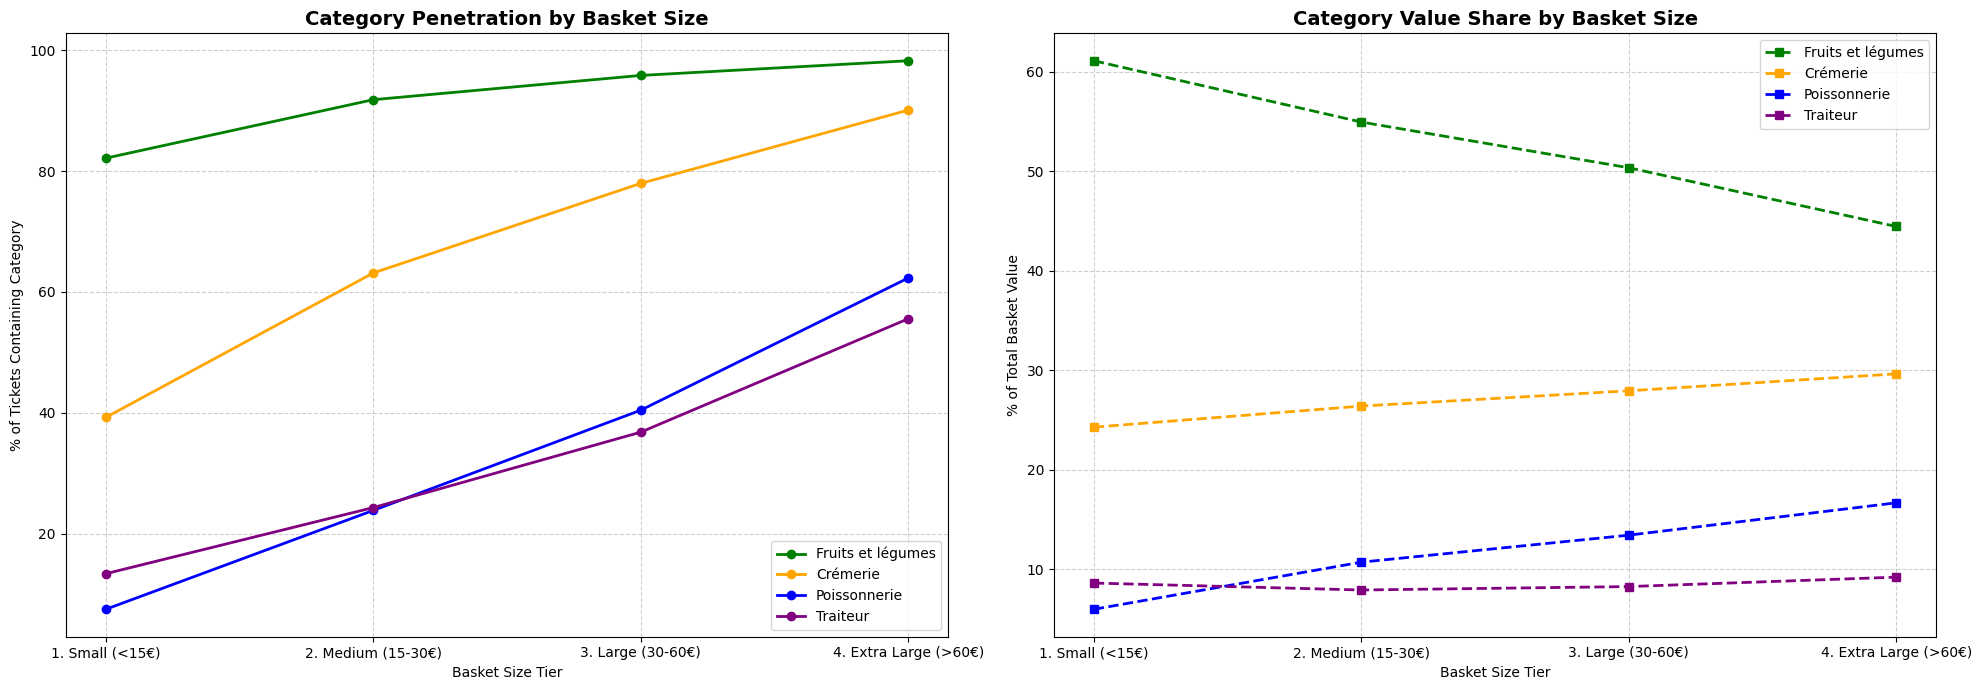

In [40]:
# Set up the figure/canvas
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Define the three main departments we want to observe
target_depts = ['Fruits et légumes', 'Crémerie', 'Poissonnerie','Traiteur']
colors = {'Fruits et légumes': 'green', 'Crémerie': 'orange', 'Poissonnerie': 'blue','Traiteur':'purple'}

# Left Plot: Category Penetration Rate evolution
for dept in target_depts:
    axes[0].plot(
        basket_evolution['Basket_Size'], 
        basket_evolution[f'{dept}_Penetration(%)'], 
        marker='o', linewidth=2, label=dept, color=colors.get(dept, 'gray')
    )
axes[0].set_title('Category Penetration by Basket Size', fontsize=14, fontweight='bold')
axes[0].set_ylabel('% of Tickets Containing Category')
axes[0].set_xlabel('Basket Size Tier')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Right Plot: Basket Value Share evolution
for dept in target_depts:
    axes[1].plot(
        basket_evolution['Basket_Size'], 
        basket_evolution[f'{dept}_Value_Share(%)'], 
        marker='s', linewidth=2, linestyle='--', label=dept, color=colors.get(dept, 'gray')
    )
axes[1].set_title('Category Value Share by Basket Size', fontsize=14, fontweight='bold')
axes[1].set_ylabel('% of Total Basket Value')
axes[1].set_xlabel('Basket Size Tier')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### ANOVA test for Poissonnerie and Traiteur

In [41]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# First, calculate the value share of Seafood (Poissonnerie) and Catering (Traiteur) for each ticket
ticket_sales['Poissonnerie_Share'] = ticket_sales['Poissonnerie'] / ticket_sales['Ticket_Total']
ticket_sales['Traiteur_Share'] = ticket_sales['Traiteur'] / ticket_sales['Ticket_Total']

# Execute ANOVA: Test whether different Basket_Sizes significantly affect the Seafood share
model_fish = ols('Poissonnerie_Share ~ C(Basket_Size)', data=ticket_sales).fit()
anova_fish = sm.stats.anova_lm(model_fish, typ=2)

# Execute ANOVA: Test whether different Basket_Sizes significantly affect the Catering (Traiteur) share
model_traiteur = ols('Traiteur_Share ~ C(Basket_Size)', data=ticket_sales).fit()
anova_traiteur = sm.stats.anova_lm(model_traiteur, typ=2)

print("ANOVA Results for Seafood Share:")
print(anova_fish)
print("\nANOVA Results for Traiteur Share:")
print(anova_traiteur)

ANOVA Results for Seafood Share:
                     sum_sq        df            F  PR(>F)
C(Basket_Size)   289.375742       3.0  2399.297614     0.0
Residual        6985.806480  173764.0          NaN     NaN

ANOVA Results for Traiteur Share:
                     sum_sq        df          F        PR(>F)
C(Basket_Size)     1.704781       3.0  15.586922  3.919451e-10
Residual        6335.001359  173764.0        NaN           NaN


**Notably, the Seafood department exhibits an exceptionally high F-statistic (2399.3). 
This demonstrates that as customers transition from 'routine produce shopping' to 'large-scale basket purchasing,' 
the surge in seafood consumption is a statistically inevitable and stable commercial behavior.**

### 11. Customer Promotional Segmentation 
**Objective:** Segment the customer base into three cohorts (Promo-Only, Mixed, Price-Insensitive) based on their historical promotional spend ratio. Further evaluate if promotions act as "main drivers" or are merely "bought in passing" across high/low-frequency segments.

In [42]:
df_transactions['IS_PROMO_ANY'] = np.where(
    (df_transactions['IS_PROMO_NATIONALE'] == 1) | (df_transactions['IS_PROMO_MAGASIN'] == 1), 
    1, 0
)

# PROMO_REVENUE & PROMO_QTY
df_transactions['PROMO_REVENUE'] = df_transactions['MT_TTC_NET'] * df_transactions['IS_PROMO_ANY']
df_transactions['PROMO_QTY'] = df_transactions['TOTAL_QTY'] * df_transactions['IS_PROMO_ANY']


In [43]:
# ==========================================
# Promo Dependency Segmentation
# ==========================================
customer_stats = df_transactions.groupby('NO_TOKEN_CB').agg(
    Total_Spend=('MT_TTC_NET', 'sum'),
    Promo_Spend=('PROMO_REVENUE', 'sum'),
    Total_Visits=('CD_TICKET_UNIQUE', 'nunique') 
).reset_index()

# Promo_Spend_Ratio
customer_stats['Promo_Ratio'] = np.where(
    customer_stats['Total_Spend'] == 0, 
    0, 
    customer_stats['Promo_Spend'] / customer_stats['Total_Spend']
)

# def Cherry Pickers vs Regulars
conditions = [
    (customer_stats['Promo_Ratio'] > 0.8),
    (customer_stats['Promo_Ratio'] >= 0.2) & (customer_stats['Promo_Ratio'] <= 0.8),
    (customer_stats['Promo_Ratio'] < 0.2)
]
choices = ['1. Promo-Only (>80%)', '2. Mixed (20-80%)', '3. Price-Insensitive (<20%)']
customer_stats['Promo_Segment'] = np.select(conditions, choices, default='Unknown')


In [44]:
# ==========================================
#  Promo Impact Across Customer Types (Main Driver vs. Bought in Passing)
# ==========================================
# Define high/low frequency customer segments (Using median here as the threshold, you can also set it to > 3 visits based on business logic)
median_visits = customer_stats['Total_Visits'].median()
customer_stats['Frequency_Segment'] = np.where(
    customer_stats['Total_Visits'] > median_visits, 
    'High Frequency', 
    'Low Frequency'
)

# To see if promos are "main drivers" or "bought in passing", we need to map customer labels back to the "Ticket" level
ticket_stats = df_transactions.groupby(['NO_TOKEN_CB', 'CD_TICKET_UNIQUE']).agg(
    Ticket_Total=('MT_TTC_NET', 'sum'),
    Ticket_Promo=('PROMO_REVENUE', 'sum')
).reset_index()

ticket_stats['Ticket_Promo_Ratio'] = np.where(
    ticket_stats['Ticket_Total'] == 0, 
    0, 
    ticket_stats['Ticket_Promo'] / ticket_stats['Ticket_Total']
)

# Merge customer segmentation features onto the ticket data
ticket_analysis = ticket_stats.merge(
    customer_stats[['NO_TOKEN_CB', 'Promo_Segment', 'Frequency_Segment']], 
    on='NO_TOKEN_CB'
)

# Only look at tickets that "contain promo items" to analyze the weight of promo items in the entire basket
promo_tickets = ticket_analysis[ticket_analysis['Ticket_Promo'] > 0]

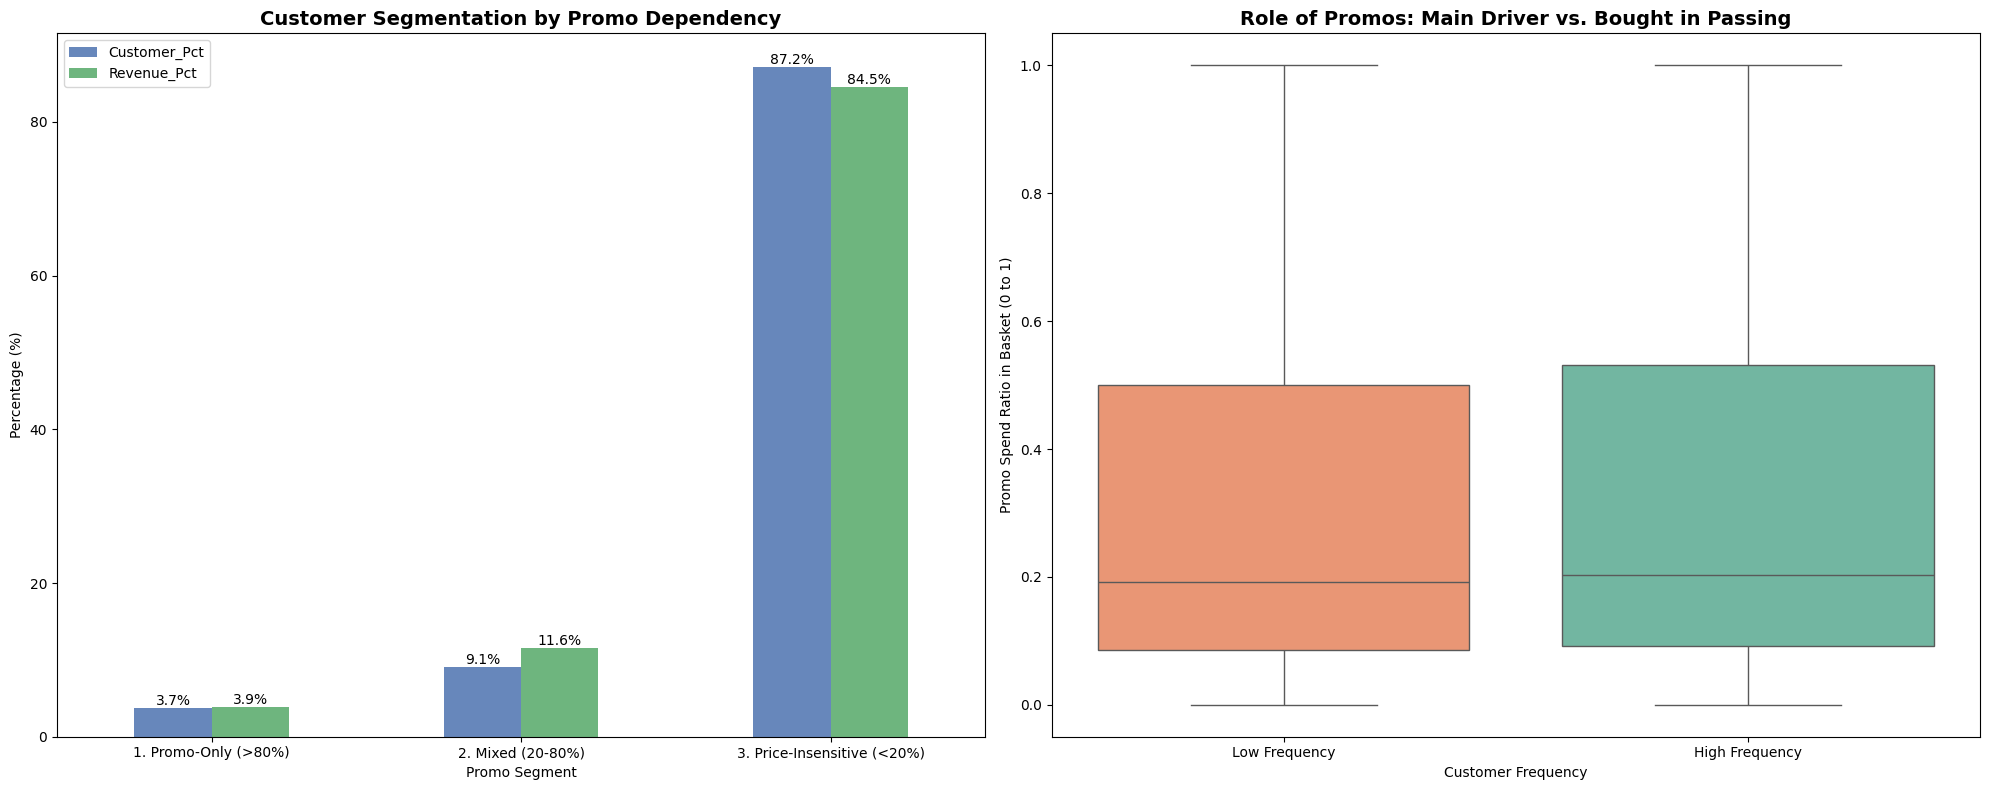

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left Plot: Customer percentage and revenue contribution (Point 2)
segment_summary = customer_stats.groupby('Promo_Segment').agg(
    Customers=('NO_TOKEN_CB', 'count'),
    Total_Revenue=('Total_Spend', 'sum')
).reset_index()
segment_summary['Customer_Pct'] = segment_summary['Customers'] / segment_summary['Customers'].sum() * 100
segment_summary['Revenue_Pct'] = segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100

# Draw bar chart for comparison
segment_summary.set_index('Promo_Segment')[['Customer_Pct', 'Revenue_Pct']].plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#55A868'], alpha=0.85
)
axes[0].set_title('Customer Segmentation by Promo Dependency', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Promo Segment')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Right Plot: Main driver or bought in passing? (Point 3)
# Observe the distribution of the promo spend ratio in the entire basket for different frequency segments among tickets that "contain promo items"
sns.boxplot(
    data=promo_tickets, 
    x='Frequency_Segment', 
    y='Ticket_Promo_Ratio', 
    hue='Frequency_Segment', 
    palette='Set2', 
    ax=axes[1],
    order=['Low Frequency', 'High Frequency'],
    legend=False             
)
axes[1].set_title('Role of Promos: Main Driver vs. Bought in Passing', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Promo Spend Ratio in Basket (0 to 1)')
axes[1].set_xlabel('Customer Frequency')

plt.tight_layout()
plt.show()

## Phase 5: Final Strategic Store Personas (Core Deliverable)

### 12. Final Store Strategy KPIs & Feature Engineering
**Objective:** Synthesize the ultimate KPI framework for strategic store evaluation. 
* **F1 to F4:** Extracted as core features for K-Means modeling (evaluating promo dependency and basket value).
* **F5 (Average Basket Units):** Calculated strictly as a post-clustering observational metric to validate if high revenue is driven by volume or premium pricing.

In [46]:
# 1. Create basic labels and features
df_transactions['IS_PROMO_ANY'] = np.where(
    (df_transactions['IS_PROMO_NATIONALE'] == 1) | (df_transactions['IS_PROMO_MAGASIN'] == 1), 1, 0
)
df_transactions['PROMO_REVENUE'] = df_transactions['MT_TTC_NET'] * df_transactions['IS_PROMO_ANY']


ticket_stats = df_transactions.groupby(['ID_LIEU_DE_VENTE', 'CD_TICKET_UNIQUE']).agg(
    Ticket_Total=('MT_TTC_NET', 'sum'),
    Ticket_Promo=('PROMO_REVENUE', 'sum'),
    Ticket_Units=('QT_UVC', 'sum') 
).reset_index()

ticket_stats['Is_Cherry_Picker'] = np.where(
    (ticket_stats['Ticket_Promo'] / np.where(ticket_stats['Ticket_Total']==0, 0.001, ticket_stats['Ticket_Total'])) > 0.8, 1, 0
)

In [47]:
# 2. Aggregate to the store level
store_features = df_transactions.groupby('ID_LIEU_DE_VENTE').agg(
    Total_Revenue=('MT_TTC_NET', 'sum'),
    Total_Promo_Rev=('PROMO_REVENUE', 'sum'),
    Fish_Total_Rev=('MT_TTC_NET', lambda x: x[df_transactions.loc[x.index, 'LB_METIER'] == 'Poissonnerie'].sum()),
    Fish_Promo_Rev=('PROMO_REVENUE', lambda x: x[df_transactions.loc[x.index, 'LB_METIER'] == 'Poissonnerie'].sum())
).reset_index()

store_tickets = ticket_stats.groupby('ID_LIEU_DE_VENTE').agg(
    Total_Tickets=('CD_TICKET_UNIQUE', 'nunique'),
    Cherry_Picker_Tickets=('Is_Cherry_Picker', 'sum'),
    F5_Avg_Basket_Units=('Ticket_Units', 'mean') 
).reset_index()

store_features = store_features.merge(store_tickets, on='ID_LIEU_DE_VENTE')

In [48]:
# 3. KPI feature
store_features['F1_Promo_Rev_Share'] = store_features['Total_Promo_Rev'] / store_features['Total_Revenue']
store_features['F2_Cherry_Picker_Ratio'] = store_features['Cherry_Picker_Tickets'] / store_features['Total_Tickets']
store_features['F3_Fish_Promo_Share'] = np.where(store_features['Fish_Total_Rev']==0, 0, store_features['Fish_Promo_Rev'] / store_features['Fish_Total_Rev'])
store_features['F4_Avg_Basket_Value'] = store_features['Total_Revenue'] / store_features['Total_Tickets']


### 13. Strategic Store Clustering (K-Means) & Persona Heatmap
**Objective:** Apply the K-Means algorithm (n_clusters=3) on the standardized F1-F4 features. Generate a Persona Heatmap to define operational tags: Cash Cows, Traffic Drivers, and Upsell Potential.

In [49]:
# 4. K-Means clustering preparation
features = [
    'F1_Promo_Rev_Share', 
    'F2_Cherry_Picker_Ratio', 
    'F3_Fish_Promo_Share', 
    'F4_Avg_Basket_Value'
]

# Extract features and standardize (Standardization is a required step for K-Means)
X = store_features[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Execute K-Means (set to 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_features['Cluster'] = kmeans.fit_predict(X_scaled)

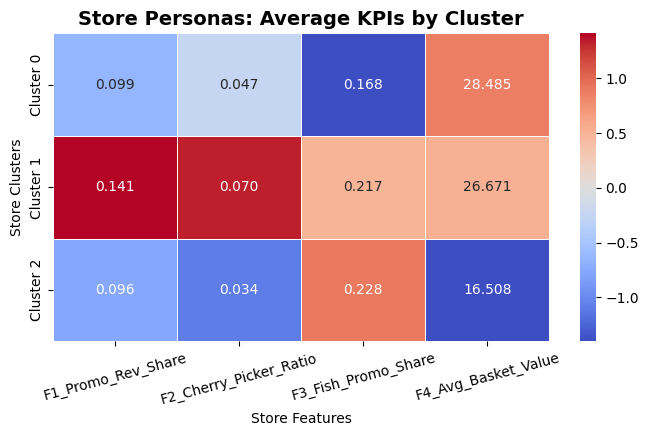

    ID_LIEU_DE_VENTE  Cluster
0                106        2
1                163        0
2                180        0
3                195        0
4                220        0
5                277        1
6                286        0
7                414        0
8                532        0
9                534        1
10               993        0


In [50]:
# 5. Plot the Cluster Persona heatmap (observe the feature centers of each cluster)
cluster_centers = store_features.groupby('Cluster')[features].mean()

# For easier visual comparison, standardize the feature centers again (Z-score) for the heatmap
scaler_heatmap = StandardScaler()
cluster_centers_scaled = pd.DataFrame(
    scaler_heatmap.fit_transform(cluster_centers), 
    columns=features, 
    index=['Cluster 0', 'Cluster 1', 'Cluster 2']
)

# heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    cluster_centers_scaled, 
    annot=cluster_centers.round(3), 
    cmap='coolwarm', 
    center=0, 
    fmt='.3f', 
    linewidths=.5
)
plt.title('Store Personas: Average KPIs by Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Store Clusters')
plt.xlabel('Store Features')
plt.xticks(rotation=15)
plt.show()

# List the cluster assigned to each store
print(store_features[['ID_LIEU_DE_VENTE', 'Cluster']])

### 14. Cross-Validation: Where do "Promo-Only" Customers Shop?
**Objective:** Merge micro-level customer segments with macro-level store clusters. This visually proves the geographic concentration of highly price-sensitive shoppers ("Cherry Pickers") and validates the localized pressure on "Traffic Driver" stores.

=== Customer Segments Distribution Across Store Clusters (%) ===


Promo_Segment,1. Promo-Only (>80%),2. Mixed (20-80%),3. Price-Insensitive (<20%)
Cluster,,,
👑 Cash Cows (Premium - Low Promo Dependency),3.4,9.0,87.6
🚨 Traffic Drivers (Promo-Driven - High Cherry Pickers),5.4,10.3,84.2
🛒 Upsell Potential (Balanced - Bought in Passing),2.6,9.0,88.5


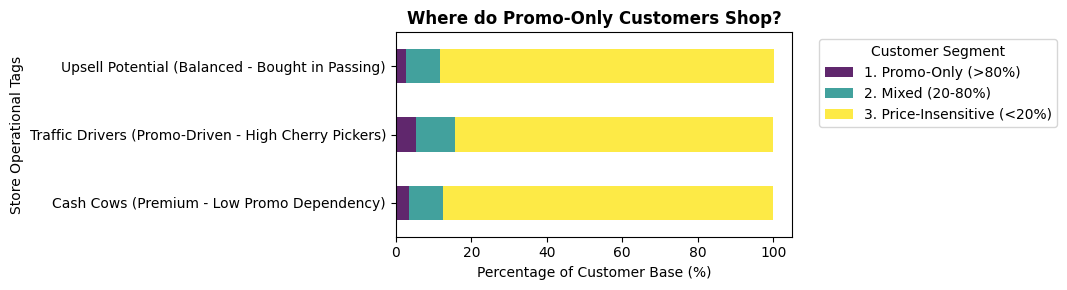

In [51]:
cluster_names = {
    0: '👑 Cash Cows (Premium - Low Promo Dependency)',
    1: '🚨 Traffic Drivers (Promo-Driven - High Cherry Pickers)',
    2: '🛒 Upsell Potential (Balanced - Bought in Passing)'
}

# 1. Merge store Cluster labels back to the transaction details (using the original df_transactions data)
ticket_with_store = df_transactions[['CD_TICKET_UNIQUE', 'ID_LIEU_DE_VENTE', 'NO_TOKEN_CB']].drop_duplicates()
ticket_with_store = ticket_with_store.merge(store_features[['ID_LIEU_DE_VENTE', 'Cluster']], on='ID_LIEU_DE_VENTE', how='left')

# 2. Merge customer Promo_Segment data (ensure customer_stats was calculated in previous steps)
ticket_with_store_cust = ticket_with_store.merge(customer_stats[['NO_TOKEN_CB', 'Promo_Segment']], on='NO_TOKEN_CB', how='left')

# 3. Ensure only customers with known segments are included
ticket_with_store_cust = ticket_with_store_cust[ticket_with_store_cust['Promo_Segment'].notna()]

# 4. Calculate the proportion of these three customer segments within each store Cluster
cluster_cust_mix = ticket_with_store_cust.groupby(['Cluster', 'Promo_Segment'])['NO_TOKEN_CB'].nunique().unstack(fill_value=0)
cluster_cust_mix_pct = cluster_cust_mix.div(cluster_cust_mix.sum(axis=1), axis=0) * 100

# 5. Add user-friendly labels and display the table (keeping Emojis in the table display)
cluster_cust_mix_pct.index = cluster_cust_mix_pct.index.map(cluster_names)
cluster_cust_mix_pct = cluster_cust_mix_pct.round(1)

print("=== Customer Segments Distribution Across Store Clusters (%) ===")
display(cluster_cust_mix_pct)

# Create a copy for plotting and strip the Emoji and space at the beginning (keep plain text after the 2nd character)
plot_data = cluster_cust_mix_pct.copy()
plot_data.index = plot_data.index.str[2:] 

# Visualize the data (using plot_data which has no Emojis to avoid font rendering errors)
plot_data.plot(kind='barh', stacked=True, figsize=(11, 3), colormap='viridis', alpha=0.85)
plt.title('Where do Promo-Only Customers Shop?', fontsize=12, fontweight='bold')
plt.xlabel('Percentage of Customer Base (%)')
plt.ylabel('Store Operational Tags')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 15. Final Deliverable: Interactive Store Strategy Map & Summary
**Objective:** Construct an interactive Folium map with hover tooltips displaying core KPIs (including F5 Average Units). Output the final operational playbook table for regional management.

In [52]:
import folium
from IPython.display import display

# 1. Merge geographic information (store_features now includes F5)
store_locations = df_transactions[['ID_LIEU_DE_VENTE', 'LB_DESIGNATION_LIEU_DE_VENTE', 'LB_VILLE', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
map_data = store_features.merge(store_locations, on='ID_LIEU_DE_VENTE', how='left')

cluster_config = {
    0: {'color': 'blue', 'icon': 'star', 'name': '👑 Cash Cows (Premium - Low Promo Dependency)'},
    1: {'color': 'red', 'icon': 'fire', 'name': '🚨 Traffic Drivers (Promo-Driven - High Cherry Pickers)'},
    2: {'color': 'green', 'icon': 'shopping-cart', 'name': '🛒 Upsell Potential (Balanced - Bought in Passing)'}
}

# 2. Generate the map (add F5 information to the Popup)
center_lat = map_data['LATITUDE'].mean()
center_lon = map_data['LONGITUDE'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='CartoDB positron') 

for idx, row in map_data.iterrows():
    cluster_id = row['Cluster']
    config = cluster_config[cluster_id]
    
    popup_html = f"""
    <div style="width: 250px; font-family: Arial, sans-serif;">
        <h4 style="margin-bottom: 5px; color: {config['color']};"><b>{row['LB_DESIGNATION_LIEU_DE_VENTE']}</b></h4>
        <p style="margin-top: 0; font-size: 14px; color: gray;">{row['LB_VILLE']}</p>
        <hr style="margin: 5px 0;">
        <b>Operational Tag:</b><br>{config['name']}<br><br>
        <b>Key KPIs:</b>
        <ul style="margin-top: 5px; padding-left: 20px;">
            <li>Promo Rev Share: <b>{row['F1_Promo_Rev_Share']*100:.1f}%</b></li>
            <li>Cherry Pickers: <b>{row['F2_Cherry_Picker_Ratio']*100:.1f}%</b></li>
            <li>Avg Basket Value: <b>{row['F4_Avg_Basket_Value']:.1f} €</b></li>
            <li>Avg Basket Units: <b>{row['F5_Avg_Basket_Units']:.1f} items</b></li> 
        </ul>
    </div>
    """
    # Create the Marker 
    folium.Marker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['LB_VILLE']} | Avg Units: {row['F5_Avg_Basket_Units']:.1f} items", 
        icon=folium.Icon(color=config['color'], icon=config['icon'], prefix='fa')
    ).add_to(m)
    

print("=== Store Strategy Map ===")
display(m)

# 3. Generate the final KPI summary report (includes F5)
cluster_names = {k: v['name'] for k, v in cluster_config.items()}

summary_table = map_data.copy()
summary_table['Operational_Tag'] = summary_table['Cluster'].map(cluster_names)
summary_table['Promo_Rev_Share(%)'] = (summary_table['F1_Promo_Rev_Share'] * 100).round(1)
summary_table['Cherry_Picker_Ratio(%)'] = (summary_table['F2_Cherry_Picker_Ratio'] * 100).round(1)
summary_table['Fish_Promo_Share(%)'] = (summary_table['F3_Fish_Promo_Share'] * 100).round(1)
summary_table['Avg_Basket_Value(€)'] = summary_table['F4_Avg_Basket_Value'].round(2)
summary_table['Avg_Basket_Units'] = summary_table['F5_Avg_Basket_Units'].round(1) 

final_display_table = summary_table[[
    'ID_LIEU_DE_VENTE', 'LB_DESIGNATION_LIEU_DE_VENTE', 'Operational_Tag', 
    'Promo_Rev_Share(%)', 'Cherry_Picker_Ratio(%)', 'Fish_Promo_Share(%)', 
    'Avg_Basket_Value(€)', 'Avg_Basket_Units' 
]].rename(columns={'ID_LIEU_DE_VENTE': 'Store_ID', 'LB_DESIGNATION_LIEU_DE_VENTE': 'Store_Name'})

final_display_table = final_display_table.sort_values('Operational_Tag')
print("\n=== Prosol Store KPI Summary ===")
display(final_display_table)


=== Store Strategy Map ===



=== Prosol Store KPI Summary ===


,Store_ID,Store_Name,Operational_Tag,Promo_Rev_Share(%),Cherry_Picker_Ratio(%),Fish_Promo_Share(%),Avg_Basket_Value(€),Avg_Basket_Units
1,163,Perpignan,👑 Cash Cows (Premium - Low Promo Dependency),10.3,5.4,17.1,34.59,9.5
2,180,Meyzieu,👑 Cash Cows (Premium - Low Promo Dependency),6.3,2.5,12.7,29.22,8.3
3,195,Hautepierre,👑 Cash Cows (Premium - Low Promo Dependency),9.9,4.7,16.5,28.46,8.8
4,220,Wasquehal,👑 Cash Cows (Premium - Low Promo Dependency),10.1,4.8,16.1,27.25,8.2
6,286,Fleury sur Orne,👑 Cash Cows (Premium - Low Promo Dependency),10.0,5.0,16.2,26.95,8.1
7,414,Mions,👑 Cash Cows (Premium - Low Promo Dependency),11.3,5.9,17.7,29.83,8.6
8,532,Decines,👑 Cash Cows (Premium - Low Promo Dependency),11.0,4.8,20.1,25.35,8.0
10,993,Hem,👑 Cash Cows (Premium - Low Promo Dependency),10.2,4.4,18.2,26.23,7.9
5,277,Polygone,🚨 Traffic Drivers (Promo-Driven - High Cherry ...,13.4,6.9,19.8,28.08,8.3
9,534,Bron,🚨 Traffic Drivers (Promo-Driven - High Cherry ...,14.9,7.1,23.6,25.26,8.2
